In [ ]:
# ============================================================
# ΚΕΛΙ 1: IMPORTS & SEED
# ============================================================
!pip install torch_geometric
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import random
from torch_geometric.nn import GATConv
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

def set_seed(seed=42):
    random.seed(seed);
    np.random.seed(seed);
    torch.manual_seed(seed);
    torch.cuda.manual_seed_all(seed);
    torch.backends.cudnn.deterministic = True;
    torch.backends.cudnn.benchmark = False;

set_seed(42);
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu');
print(f"✅ Device: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.1 MB/s eta 0:00:00
✅ Device: cpu


In [ ]:
# ============================================================
# ΚΕΛΙ 2: ΦΟΡΤΩΣΗ ΔΕΔΟΜΕΝΩΝ & ΚΑΤΑΣΚΕΥΗ ΓΡΑΦΟΥ
# ============================================================
df_pos = pd.read_csv('positive_protein_sequences.csv')
df_neg = pd.read_csv('negative_protein_sequences.csv')
col_A, col_B = df_pos.columns[0], df_pos.columns[1]

# Mapping πρωτεϊνών → αριθμός
all_proteins = (set(df_pos[col_A]) | set(df_pos[col_B]) |
                set(df_neg[col_A]) | set(df_neg[col_B]))
protein_to_idx = {p: i for i, p in enumerate(sorted(all_proteins))}
num_nodes = len(protein_to_idx)
print(f"✅ Μοναδικές πρωτεΐνες (κόμβοι): {num_nodes}")

def to_edge_tensor(df):
    src = [protein_to_idx[p] for p in df[col_A]]
    dst = [protein_to_idx[p] for p in df[col_B]]
    return torch.tensor([src, dst], dtype=torch.long)

pos_edge_index = to_edge_tensor(df_pos)
neg_edge_index = to_edge_tensor(df_neg)

# Split 80/20
pos_tr, pos_te = train_test_split(range(pos_edge_index.shape[1]), test_size=0.2, random_state=42)
neg_tr, neg_te = train_test_split(range(neg_edge_index.shape[1]), test_size=0.2, random_state=42)

train_edge_label_index = torch.cat([pos_edge_index[:, pos_tr], neg_edge_index[:, neg_tr]], dim=1).to(device)
test_edge_label_index  = torch.cat([pos_edge_index[:, pos_te], neg_edge_index[:, neg_te]], dim=1).to(device)
train_labels = torch.cat([torch.ones(len(pos_tr)), torch.zeros(len(neg_tr))]).to(device)
test_labels  = torch.cat([torch.ones(len(pos_te)), torch.zeros(len(neg_te))]).to(device)

# Γράφος (μόνο θετικά training edges)
data = Data(x=torch.arange(num_nodes).unsqueeze(1),
            edge_index=pos_edge_index[:, pos_tr]).to(device)
print(f"✅ Γράφος: {data.num_nodes} κόμβοι, {data.num_edges} ακμές")

✅ Μοναδικές πρωτεΐνες (κόμβοι): 10344
✅ Γράφος: 10344 κόμβοι, 29304 ακμές


In [ ]:
# ============================================================
# ΚΕΛΙ 3: GAT ΜΟΝΤΕΛΟ & ΕΚΠΑΙΔΕΥΣΗ
# ============================================================
class GATLinkPredictor(nn.Module):
    def __init__(self, num_nodes, emb_dim=64, hidden=64, heads=4):
        super().__init__()
        self.node_emb = nn.Embedding(num_nodes, emb_dim)
        self.conv1 = GATConv(emb_dim, hidden, heads=heads, dropout=0.3)
        self.conv2 = GATConv(hidden * heads, hidden, heads=1, concat=False, dropout=0.3)

    def encode(self, x, edge_index):
        x = self.node_emb.weight
        x = self.conv1(x, edge_index).relu()
        return self.conv2(x, edge_index)

    def decode(self, z, edge_index):
        return (z[edge_index[0]] * z[edge_index[1]]).sum(dim=-1)

set_seed(42)
model = GATLinkPredictor(num_nodes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()

for epoch in range(1, 101):
    model.train()
    optimizer.zero_grad()
    z = model.encode(data.x, data.edge_index)
    loss = criterion(model.decode(z, train_edge_label_index), train_labels)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        model.eval()
        with torch.no_grad():
            z = model.encode(data.x, data.edge_index)
            auc = roc_auc_score(test_labels.cpu().numpy(),
                                model.decode(z, test_edge_label_index).sigmoid().cpu().numpy())
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | AUC: {auc:.4f}")

print("✅ Εκπαίδευση GAT ολοκληρώθηκε.")

Epoch 020 | Loss: 0.6823 | AUC: 0.5304
Epoch 040 | Loss: 0.4992 | AUC: 0.8909
Epoch 060 | Loss: 0.4265 | AUC: 0.9297
Epoch 080 | Loss: 0.3794 | AUC: 0.9448
Epoch 100 | Loss: 0.3197 | AUC: 0.9544
✅ Εκπαίδευση GAT ολοκληρώθηκε.


In [ ]:
# ============================================================
# ΚΕΛΙ 4: ESM-2 EMBEDDINGS & HYBRID FUSION
# ============================================================
part1 = np.load('esm2_embeddings_1.npy')
part2 = np.load('esm2_embeddings_2.npy')
esm_full = np.concatenate([part1, part2], axis=0)
print(f"✅ ESM-2 Loaded: {esm_full.shape}")

# Alignment: κάθε πρωτεΐνη → σωστή γραμμή
full_df = pd.concat([df_pos, df_neg], ignore_index=True)
raw_names = [n for _, row in full_df.iterrows() for n in [row[col_A], row[col_B]]]
prot_to_emb = {}
for i, name in enumerate(raw_names):
    if i < len(esm_full) and name not in prot_to_emb:
        prot_to_emb[name] = esm_full[i]

aligned = np.zeros((num_nodes, esm_full.shape[1]))
for prot, idx in protein_to_idx.items():
    if prot in prot_to_emb:
        aligned[idx] = prot_to_emb[prot]

aligned_esm_emb = torch.tensor(aligned, dtype=torch.float).to(device)

# GAT & Hybrid embeddings
model.eval()
with torch.no_grad():
    gat_emb = model.encode(data.x, data.edge_index)

hybrid_emb = torch.cat([gat_emb, aligned_esm_emb], dim=1)
print(f"✅ GAT emb: {gat_emb.shape} | ESM emb: {aligned_esm_emb.shape} | Hybrid: {hybrid_emb.shape}")

✅ ESM-2 Loaded: (146220, 480)
✅ GAT emb: torch.Size([10344, 64]) | ESM emb: torch.Size([10344, 480]) | Hybrid: torch.Size([10344, 544])



📊 ΠΙΝΑΚΑΣ ΑΠΟΤΕΛΕΣΜΑΤΩΝ:
                       Accuracy  F1-Score  Precision  Recall  AUC-ROC    TP   FP    TN    FN
Model                                                                                       
ESM-2 (Sequence Only)    0.8435    0.8315     0.9027  0.7708   0.9283  5647  609  6687  1679
GAT (Topology Only)      0.9696    0.9691     0.9895  0.9495   0.9934  6956   74  7222   370
Hybrid (ESM-2 + GAT)     0.9776    0.9774     0.9910  0.9641   0.9940  7063   64  7232   263


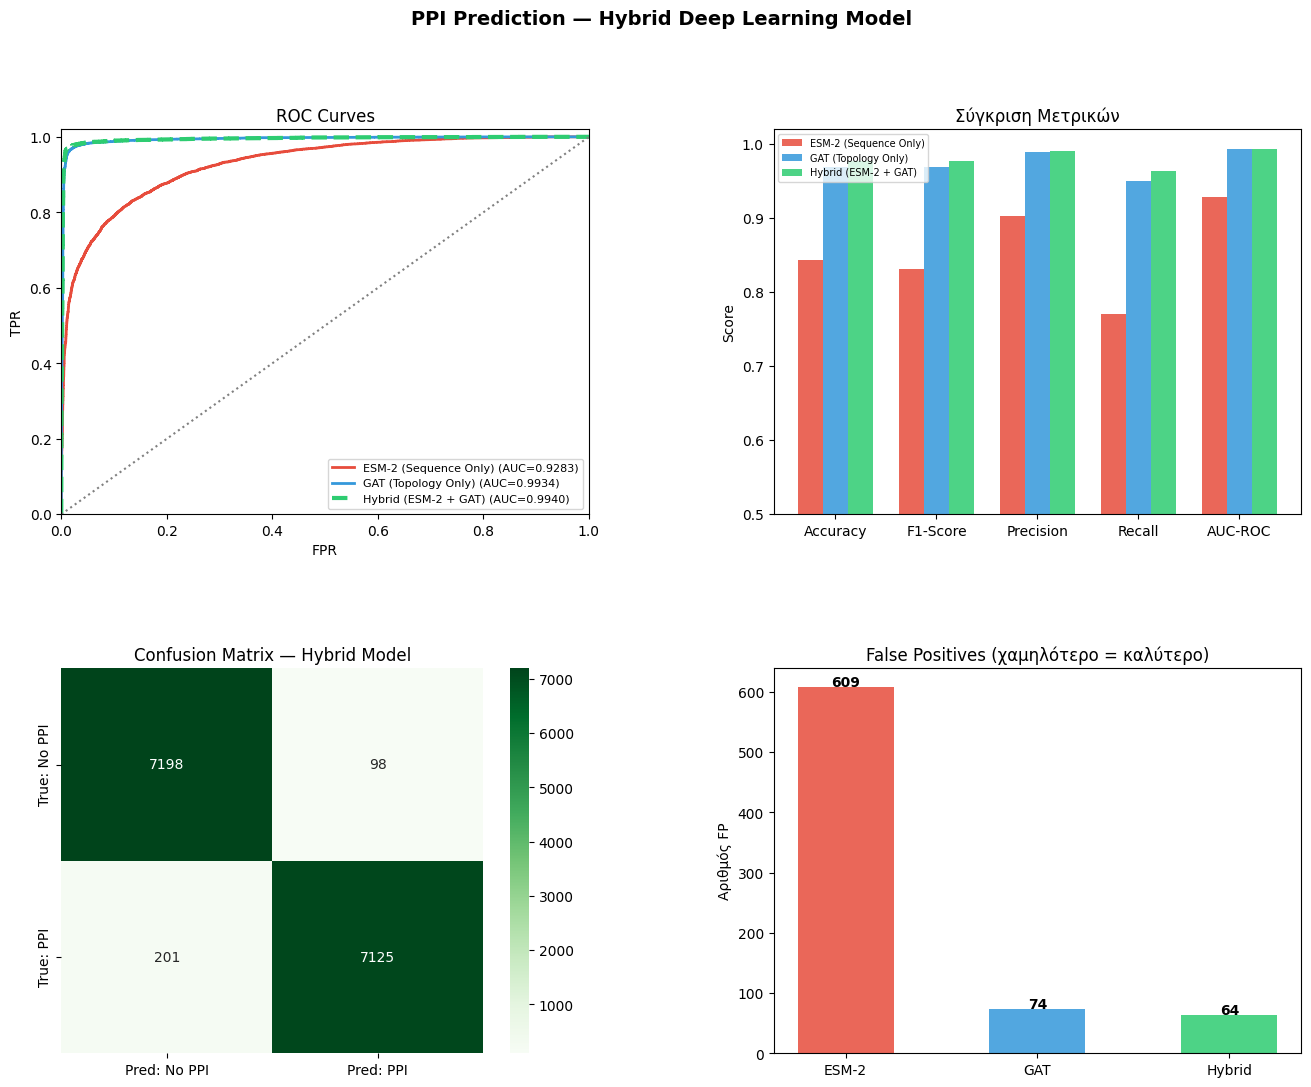

✅ Αποθηκεύτηκε ως 'results_thesis.png'


In [ ]:
# ============================================================
# ΚΕΛΙ 5: ΤΕΛΙΚΗ ΑΞΙΟΛΟΓΗΣΗ & ΓΡΑΦΗΜΑΤΑ
# ============================================================
def evaluate(embeddings, name, epochs=100):
    set_seed(42)
    clf = nn.Sequential(
        nn.Linear(embeddings.shape[1] * 2, 128),
        nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(128, 64), nn.ReLU(),
        nn.Linear(64, 1)
    ).to(device)
    opt = torch.optim.Adam(clf.parameters(), lr=0.005)
    loss_fn = nn.BCEWithLogitsLoss()

    clf.train()
    for _ in range(epochs):
        opt.zero_grad()
        pair = torch.cat([embeddings[train_edge_label_index[0]],
                          embeddings[train_edge_label_index[1]]], dim=1)
        loss_fn(clf(pair).squeeze(), train_labels).backward()
        opt.step()

    clf.eval()
    with torch.no_grad():
        pair_t = torch.cat([embeddings[test_edge_label_index[0]],
                            embeddings[test_edge_label_index[1]]], dim=1)
        probs = torch.sigmoid(clf(pair_t).squeeze()).cpu().numpy()
        preds = (probs > 0.75).astype(int)
        y     = test_labels.cpu().numpy()
        tn, fp, fn, tp = confusion_matrix(y, preds).ravel()
    return {
        "Model": name, "probs": probs,
        "Accuracy": round(accuracy_score(y, preds), 4),
        "F1-Score": round(f1_score(y, preds), 4),
        "Precision": round(precision_score(y, preds), 4),
        "Recall": round(recall_score(y, preds), 4),
        "AUC-ROC": round(roc_auc_score(y, probs), 4),
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn)
    }

r_esm = evaluate(aligned_esm_emb, "ESM-2 (Sequence Only)")
r_gat = evaluate(gat_emb,         "GAT (Topology Only)")
r_hyb = evaluate(hybrid_emb,      "Hybrid (ESM-2 + GAT)")
results = [r_esm, r_gat, r_hyb]

# ── Πίνακας ─────────────────────────────────────────────────
metrics_cols = ["Accuracy","F1-Score","Precision","Recall","AUC-ROC","TP","FP","TN","FN"]
df_res = pd.DataFrame(results).set_index("Model")[metrics_cols]
print("\n📊 ΠΙΝΑΚΑΣ ΑΠΟΤΕΛΕΣΜΑΤΩΝ:")
print(df_res.to_string())

# ── Γραφήματα ────────────────────────────────────────────────
COLORS = {"ESM-2 (Sequence Only)":"#e74c3c",
          "GAT (Topology Only)":"#3498db",
          "Hybrid (ESM-2 + GAT)":"#2ecc71"}
y_true = test_labels.cpu().numpy()

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# ROC Curves
ax1 = fig.add_subplot(gs[0, 0])
for r in results:
    fpr, tpr, _ = roc_curve(y_true, r["probs"])
    lbl = f'{r["Model"]} (AUC={roc_auc_score(y_true, r["probs"]):.4f})'
    ax1.plot(fpr, tpr, color=COLORS[r["Model"]],
             lw=3 if "Hybrid" in r["Model"] else 2,
             ls="--" if "Hybrid" in r["Model"] else "-", label=lbl)
ax1.plot([0,1],[0,1],'gray',ls=':')
ax1.set(title="ROC Curves", xlabel="FPR", ylabel="TPR", xlim=[0,1], ylim=[0,1.02])
ax1.legend(fontsize=8)

# Bar Chart μετρικών
ax2 = fig.add_subplot(gs[0, 1])
m_keys = ["Accuracy","F1-Score","Precision","Recall","AUC-ROC"]
x, w = np.arange(len(m_keys)), 0.25
for i, r in enumerate(results):
    ax2.bar(x + i*w, [r[k] for k in m_keys], w,
            label=r["Model"], color=COLORS[r["Model"]], alpha=0.85)
ax2.set(xticks=x+w, xticklabels=m_keys, ylim=[0.5,1.02],
        title="Σύγκριση Μετρικών", ylabel="Score")
ax2.legend(fontsize=7)

# Confusion Matrix (Hybrid)
ax3 = fig.add_subplot(gs[1, 0])
cm_hyb = confusion_matrix(y_true, (r_hyb["probs"] > 0.5).astype(int))
sns.heatmap(cm_hyb, annot=True, fmt="d", cmap="Greens", ax=ax3,
            xticklabels=["Pred: No PPI","Pred: PPI"],
            yticklabels=["True: No PPI","True: PPI"])
ax3.set(title="Confusion Matrix — Hybrid Model")

# False Positives
ax4 = fig.add_subplot(gs[1, 1])
bars = ax4.bar([r["Model"].split()[0] for r in results],
               [r["FP"] for r in results],
               color=[COLORS[r["Model"]] for r in results], width=0.5, alpha=0.85)
for b in bars:
    ax4.text(b.get_x()+b.get_width()/2, b.get_height()+1,
             str(int(b.get_height())), ha="center", fontweight="bold")
ax4.set(title="False Positives (χαμηλότερο = καλύτερο)", ylabel="Αριθμός FP")

plt.suptitle("PPI Prediction — Hybrid Deep Learning Model", fontsize=14, fontweight="bold")
plt.savefig("results_thesis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Αποθηκεύτηκε ως 'results_thesis.png'")

🕵️ Έλεγχος Overfitting για όλα τα μοντέλα...
⏳ ESM-2...
⏳ GAT...
⏳ Hybrid (200 εποχές + weight 1.2)...


/tmp/ipykernel_2962/3659755353.py:141: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("overfitting_check.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


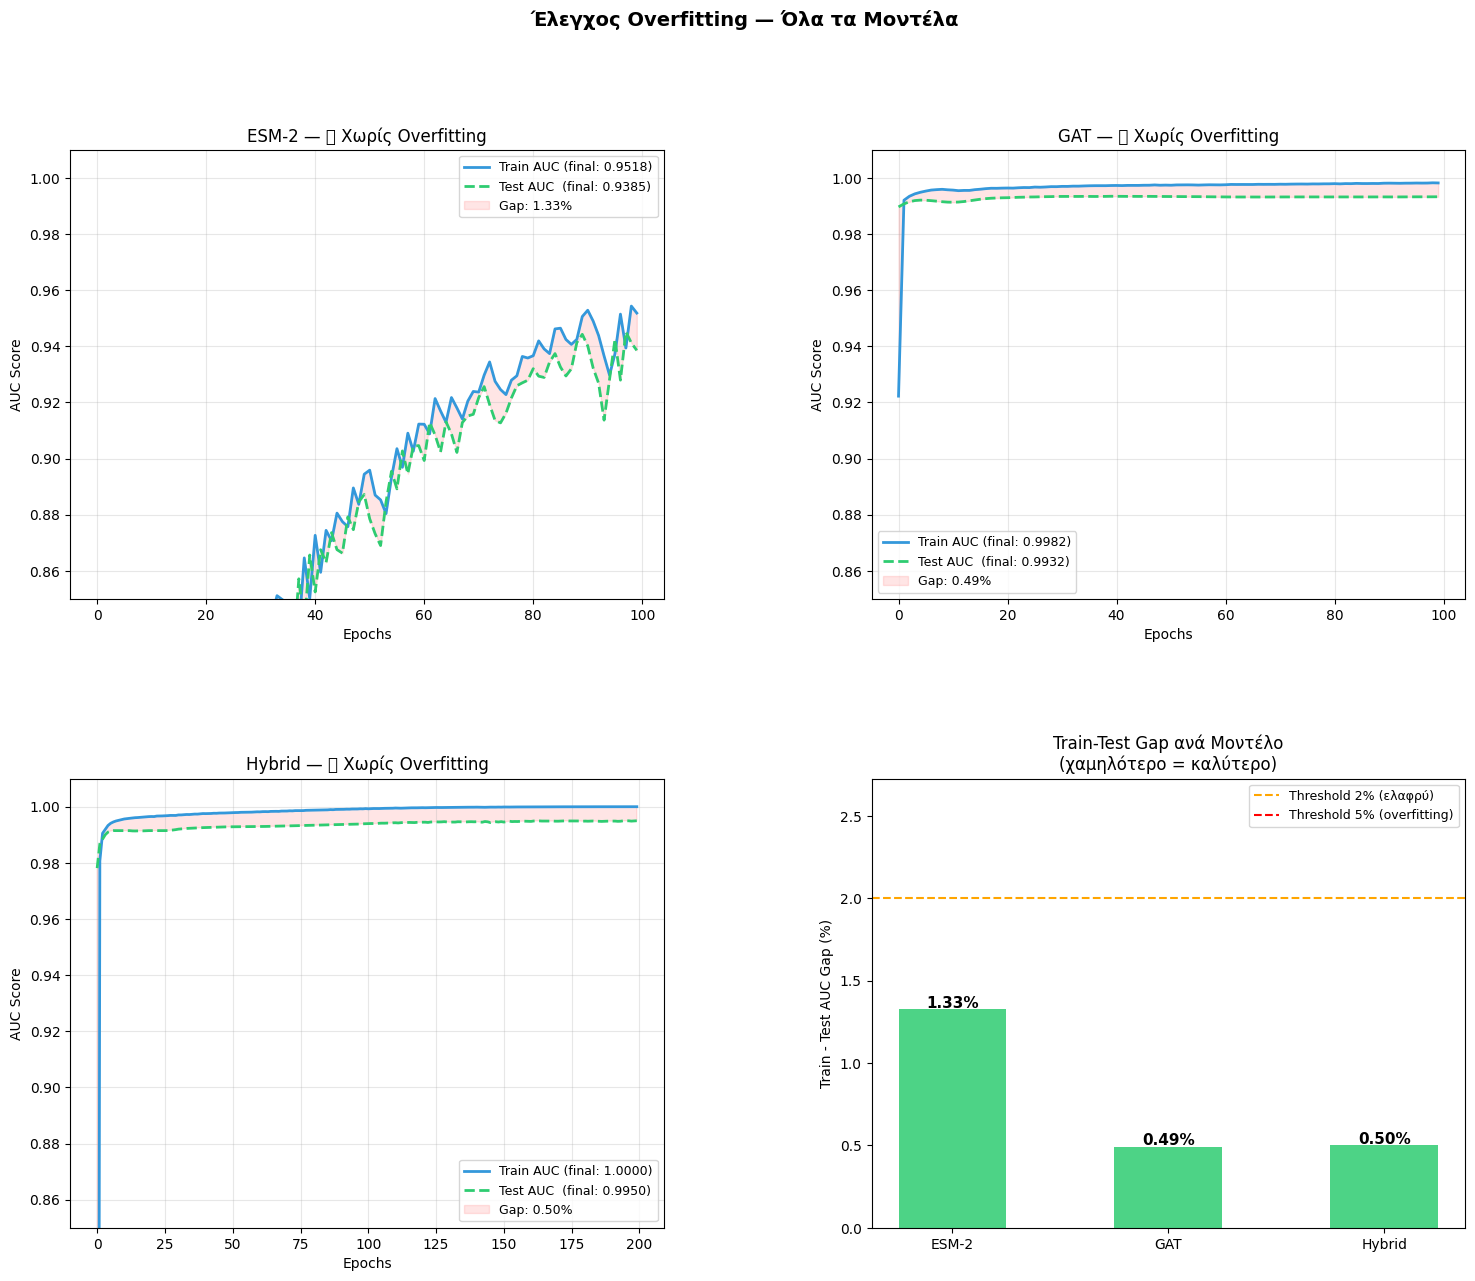


📊 ΣΥΝΟΨΗ ΕΛΕΓΧΟΥ OVERFITTING:
  ESM-2      | Gap: 1.33% | ✅ ΟΚ
  GAT        | Gap: 0.49% | ✅ ΟΚ
  Hybrid     | Gap: 0.50% | ✅ ΟΚ

✅ Αποθηκεύτηκε: overfitting_check.png


In [ ]:
# ============================================================
# ΚΕΛΙ 18: ΕΛΕΓΧΟΣ OVERFITTING — ΟΛΑ ΤΑ ΜΟΝΤΕΛΑ
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_auc_score
import torch
import torch.nn as nn
import numpy as np

set_seed(42)
print("🕵️ Έλεγχος Overfitting για όλα τα μοντέλα...")

def overfitting_check(embeddings, name, epochs=100, dropout=0.2, pos_weight=1.0):
    input_dim  = embeddings.shape[1]
    classifier = nn.Sequential(
        nn.Linear(input_dim * 2, 128),
        nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(128, 64), nn.ReLU(),
        nn.Linear(64, 1)
    ).to(device)

    opt     = torch.optim.Adam(classifier.parameters(), lr=0.005)
    loss_fn = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight]).to(device))

    train_aucs, test_aucs = [], []

    for epoch in range(epochs):
        # Train
        classifier.train()
        opt.zero_grad()
        src  = embeddings[train_edge_label_index[0]]
        dst  = embeddings[train_edge_label_index[1]]
        pair = torch.cat([src, dst], dim=1)
        out  = classifier(pair).squeeze()
        loss_fn(out, train_labels).backward()
        opt.step()

        # Eval
        classifier.eval()
        with torch.no_grad():
            # Train AUC
            tr_auc = roc_auc_score(
                train_labels.cpu().numpy(),
                torch.sigmoid(out).cpu().numpy())

            # Test AUC
            src_t  = embeddings[test_edge_label_index[0]]
            dst_t  = embeddings[test_edge_label_index[1]]
            pair_t = torch.cat([src_t, dst_t], dim=1)
            te_auc = roc_auc_score(
                test_labels.cpu().numpy(),
                torch.sigmoid(classifier(pair_t).squeeze()).cpu().numpy())

        train_aucs.append(tr_auc)
        test_aucs.append(te_auc)

    gap = train_aucs[-1] - test_aucs[-1]
    return train_aucs, test_aucs, gap

# ── Τρέχουμε για όλα τα μοντέλα ──────────────────────────────
esm_var = aligned_esm_emb if 'aligned_esm_emb' in dir() else esm_emb

print("⏳ ESM-2...")
tr_esm, te_esm, gap_esm = overfitting_check(
    esm_var, "ESM-2", epochs=100)

print("⏳ GAT...")
tr_gat, te_gat, gap_gat = overfitting_check(
    gat_emb, "GAT", epochs=100)

print("⏳ Hybrid (200 εποχές + weight 1.2)...")
tr_hyb, te_hyb, gap_hyb = overfitting_check(
    hybrid_emb, "Hybrid", epochs=200,
    dropout=0.2, pos_weight=1.2)

# ── Γραφήματα ────────────────────────────────────────────────
COLORS = {
    "train": "#3498db",
    "test" : "#2ecc71"
}

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

configs = [
    ("ESM-2",   tr_esm, te_esm, gap_esm, gs[0,0]),
    ("GAT",     tr_gat, te_gat, gap_gat, gs[0,1]),
    ("Hybrid",  tr_hyb, te_hyb, gap_hyb, gs[1,0]),
]

for name, tr, te, gap, pos in configs:
    ax = fig.add_subplot(pos)
    ax.plot(tr, color=COLORS["train"], lw=2,
            label=f"Train AUC (final: {tr[-1]:.4f})")
    ax.plot(te, color=COLORS["test"], lw=2, ls="--",
            label=f"Test AUC  (final: {te[-1]:.4f})")

    # Shading της διαφοράς
    ax.fill_between(range(len(tr)), tr, te,
                    alpha=0.1, color="red",
                    label=f"Gap: {gap*100:.2f}%")

    verdict = "✅ Χωρίς Overfitting" if gap < 0.02 else \
              "🟡 Ελαφρύ Overfitting" if gap < 0.05 else \
              "⚠️ Overfitting"

    ax.set(title=f"{name} — {verdict}",
           xlabel="Epochs", ylabel="AUC Score",
           ylim=[0.85, 1.01])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# ── Summary Bar Chart ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
models = ["ESM-2", "GAT", "Hybrid"]
gaps   = [gap_esm*100, gap_gat*100, gap_hyb*100]
colors = ["#e74c3c" if g > 5 else
          "#f39c12" if g > 2 else
          "#2ecc71" for g in gaps]

bars = ax4.bar(models, gaps, color=colors, alpha=0.85, width=0.5)
for bar, g in zip(bars, gaps):
    ax4.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.01,
             f"{g:.2f}%", ha="center",
             fontweight="bold", fontsize=11)

ax4.axhline(y=2, color="orange", ls="--", lw=1.5,
            label="Threshold 2% (ελαφρύ)")
ax4.axhline(y=5, color="red", ls="--", lw=1.5,
            label="Threshold 5% (overfitting)")
ax4.set(title="Train-Test Gap ανά Μοντέλο\n(χαμηλότερο = καλύτερο)",
        ylabel="Train - Test AUC Gap (%)",
        ylim=[0, max(gaps)*1.3+1])
ax4.legend(fontsize=9)

plt.suptitle("Έλεγχος Overfitting — Όλα τα Μοντέλα",
             fontsize=14, fontweight="bold")
plt.savefig("overfitting_check.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Τελικό Συμπέρασμα ─────────────────────────────────────────
print("\n" + "="*55)
print("📊 ΣΥΝΟΨΗ ΕΛΕΓΧΟΥ OVERFITTING:")
print("="*55)
for name, gap in zip(models, gaps):
    verdict = "✅ ΟΚ" if gap < 2 else \
              "🟡 Ελαφρύ" if gap < 5 else \
              "⚠️ Overfitting"
    print(f"  {name:10} | Gap: {gap:.2f}% | {verdict}")

print("\n✅ Αποθηκεύτηκε: overfitting_check.png")

In [ ]:
# ============================================================
# ΚΕΛΙ 6: DEEPSHAP — ΕΓΚΑΤΑΣΤΑΣΗ & ΠΡΟΕΤΟΙΜΑΣΙΑ
# ============================================================
!pip install shap -q

import shap
shap.initjs()

# Εκπαιδεύουμε τον τελικό classifier που θα εξηγήσουμε
set_seed(42)
input_dim = hybrid_emb.shape[1]  # 544

final_clf = nn.Sequential(
    nn.Linear(input_dim * 2, 128),
    nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 1)
).to(device)

opt      = torch.optim.Adam(final_clf.parameters(), lr=0.005)
loss_fn  = nn.BCEWithLogitsLoss()

final_clf.train()
for _ in range(100):
    opt.zero_grad()
    pair = torch.cat([hybrid_emb[train_edge_label_index[0]],
                      hybrid_emb[train_edge_label_index[1]]], dim=1)
    loss_fn(final_clf(pair).squeeze(), train_labels).backward()
    opt.step()

final_clf.eval()
print("✅ Classifier εκπαιδεύτηκε (100 εποχές).")

✅ Classifier εκπαιδεύτηκε (100 εποχές).


In [ ]:
# ============================================================
# ΚΕΛΙ 7: DEEPSHAP — ΥΠΟΛΟΓΙΣΜΟΣ SHAP VALUES
# ============================================================

# Φτιάχνουμε τα ζεύγη (pairs) για train και test
with torch.no_grad():
    train_pairs = torch.cat([hybrid_emb[train_edge_label_index[0]],
                             hybrid_emb[train_edge_label_index[1]]], dim=1)
    test_pairs  = torch.cat([hybrid_emb[test_edge_label_index[0]],
                             hybrid_emb[test_edge_label_index[1]]], dim=1)

# Baseline: μέσος όρος 200 training ζευγών
background = train_pairs[:200]

# DeepExplainer — χρησιμοποιεί το neural network απευθείας
explainer   = shap.DeepExplainer(final_clf, background)

# Υπολογισμός SHAP values σε 200 test ζεύγη (γρήγορο)
test_sample = test_pairs[:200]
shap_values = explainer.shap_values(test_sample)

# shap_values έχει shape [200, 1088]
# Οι πρώτες 544 διαστάσεις → Πρωτεΐνη Α
# Οι τελευταίες 544 διαστάσεις → Πρωτεΐνη Β
shap_arr = shap_values[0] if isinstance(shap_values, list) else shap_values
print(f"✅ SHAP values υπολογίστηκαν. Shape: {shap_arr.shape}")

✅ SHAP values υπολογίστηκαν. Shape: (200, 1088, 1)


/tmp/ipykernel_664/2429886309.py:21: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


<Figure size 640x480 with 0 Axes>

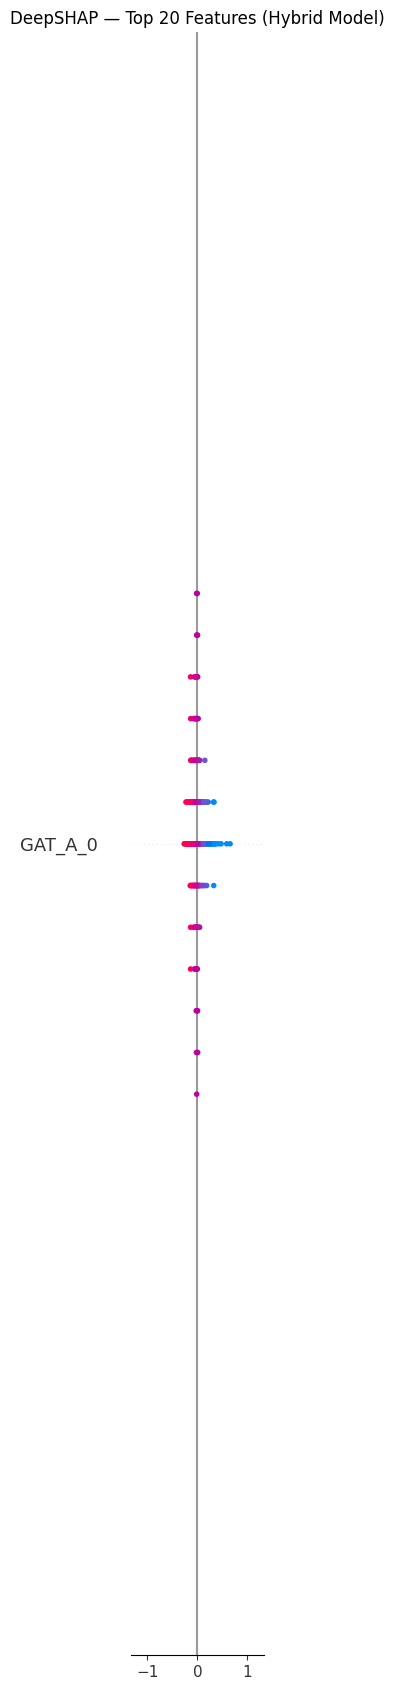

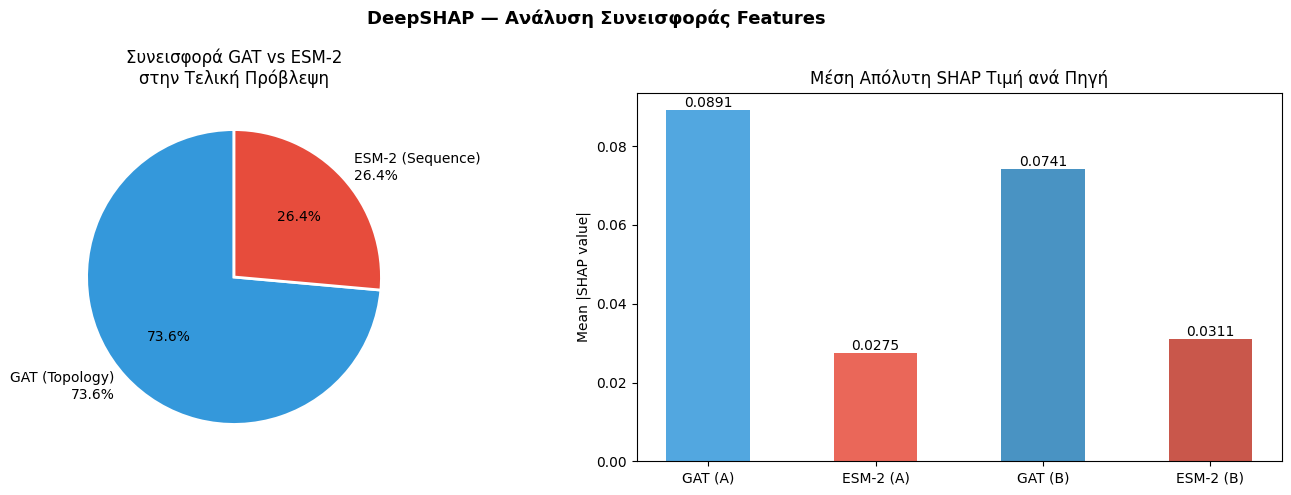

✅ Αποθηκεύτηκαν: shap_summary.png, shap_contribution.png


In [ ]:
# ============================================================
# ΚΕΛΙ 8: DEEPSHAP — ΓΡΑΦΗΜΑΤΑ
# ============================================================

# Δημιουργούμε ονόματα features
# Οι 64 πρώτες διαστάσεις = GAT, οι 480 = ESM (ανά πρωτεΐνη)
gat_dim = gat_emb.shape[1]   # 64
esm_dim = aligned_esm_emb.shape[1]  # 480

feature_names = (
    [f"GAT_A_{i}"  for i in range(gat_dim)] +
    [f"ESM_A_{i}"  for i in range(esm_dim)] +
    [f"GAT_B_{i}"  for i in range(gat_dim)] +
    [f"ESM_B_{i}"  for i in range(esm_dim)]
)

test_sample_np = test_sample.cpu().numpy()

# ── Γράφημα 1: Summary Plot (Top 20 features) ───────────────
plt.figure()
shap.summary_plot(
    shap_arr,
    test_sample_np,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title("DeepSHAP — Top 20 Features (Hybrid Model)")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Γράφημα 2: GAT vs ESM Συνεισφορά ────────────────────────
shap_abs = np.abs(shap_arr)  # απόλυτες τιμές

# Χωρίζουμε τις διαστάσεις ανά πηγή
gat_A_contrib = shap_abs[:, :gat_dim].mean()
esm_A_contrib = shap_abs[:, gat_dim:gat_dim+esm_dim].mean()
gat_B_contrib = shap_abs[:, gat_dim+esm_dim:gat_dim+esm_dim+gat_dim].mean()
esm_B_contrib = shap_abs[:, gat_dim+esm_dim+gat_dim:].mean()

gat_total = gat_A_contrib + gat_B_contrib
esm_total = esm_A_contrib + esm_B_contrib
total     = gat_total + esm_total

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(
    [gat_total, esm_total],
    labels=[f"GAT (Topology)\n{gat_total/total*100:.1f}%",
            f"ESM-2 (Sequence)\n{esm_total/total*100:.1f}%"],
    colors=["#3498db", "#e74c3c"],
    autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[0].set_title("Συνεισφορά GAT vs ESM-2\nστην Τελική Πρόβλεψη")

# Bar chart ανά πρωτεΐνη
bars = axes[1].bar(
    ["GAT (Α)", "ESM-2 (Α)", "GAT (Β)", "ESM-2 (Β)"],
    [gat_A_contrib, esm_A_contrib, gat_B_contrib, esm_B_contrib],
    color=["#3498db","#e74c3c","#2980b9","#c0392b"],
    alpha=0.85, width=0.5
)
for b in bars:
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height(),
                 f"{b.get_height():.4f}", ha="center", va="bottom", fontsize=10)
axes[1].set(title="Μέση Απόλυτη SHAP Τιμή ανά Πηγή",
            ylabel="Mean |SHAP value|")

plt.suptitle("DeepSHAP — Ανάλυση Συνεισφοράς Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_contribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Αποθηκεύτηκαν: shap_summary.png, shap_contribution.png")

/tmp/ipykernel_664/2002180281.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664/2002180281.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"waterfall_rank{rank+1:02d}.png", dpi=120, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


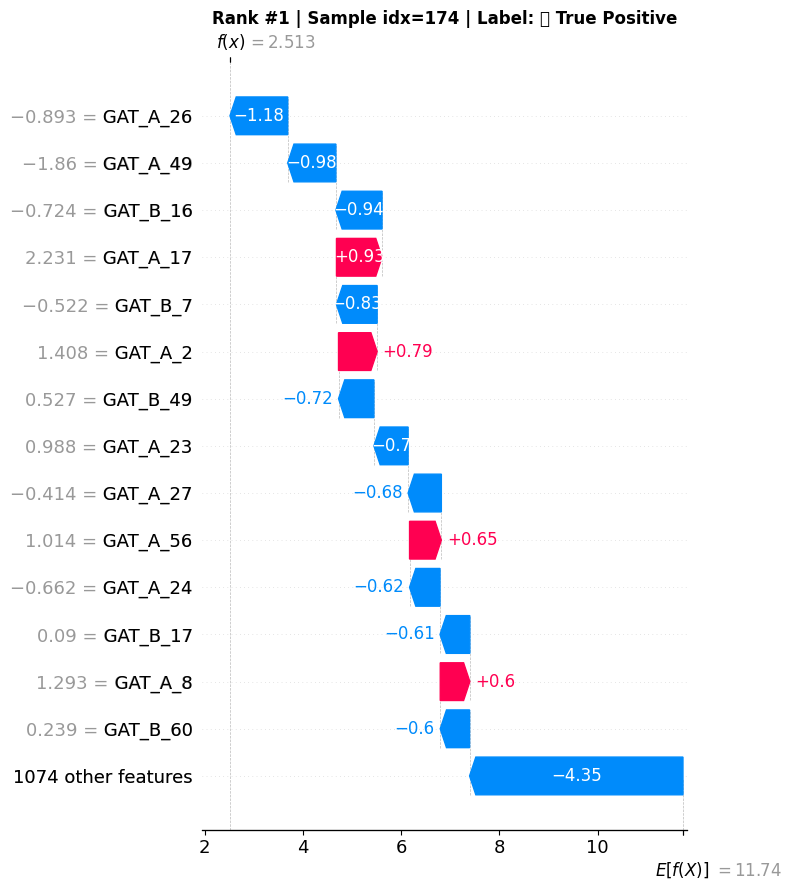

✅ Rank #1 αποθηκεύτηκε (label=1)


/tmp/ipykernel_664/2002180281.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664/2002180281.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"waterfall_rank{rank+1:02d}.png", dpi=120, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


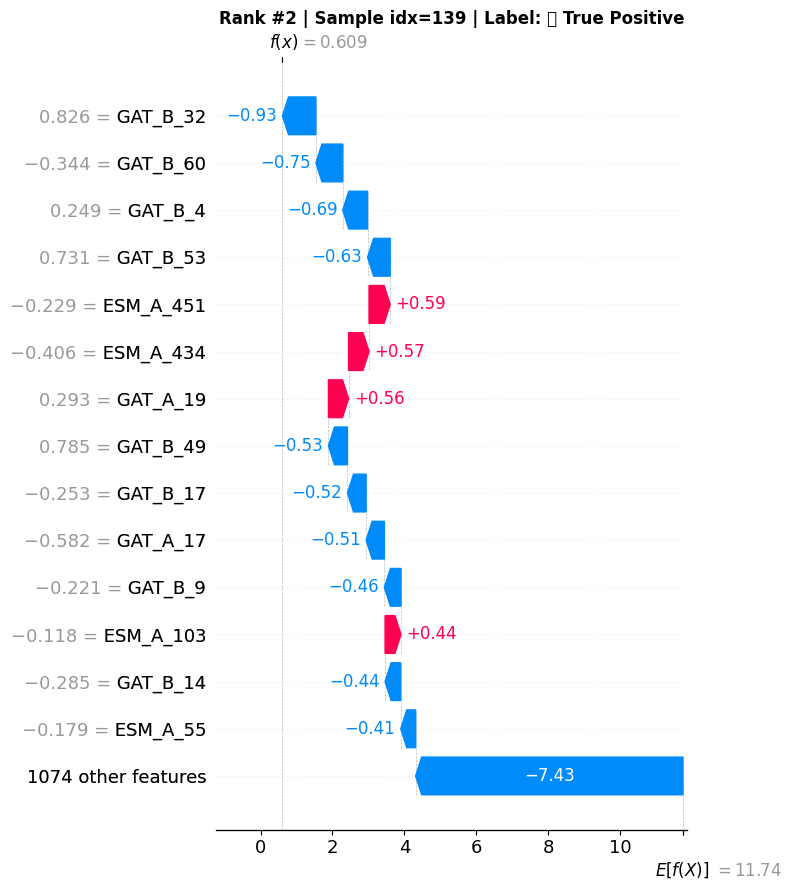

✅ Rank #2 αποθηκεύτηκε (label=1)


/tmp/ipykernel_664/2002180281.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664/2002180281.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"waterfall_rank{rank+1:02d}.png", dpi=120, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


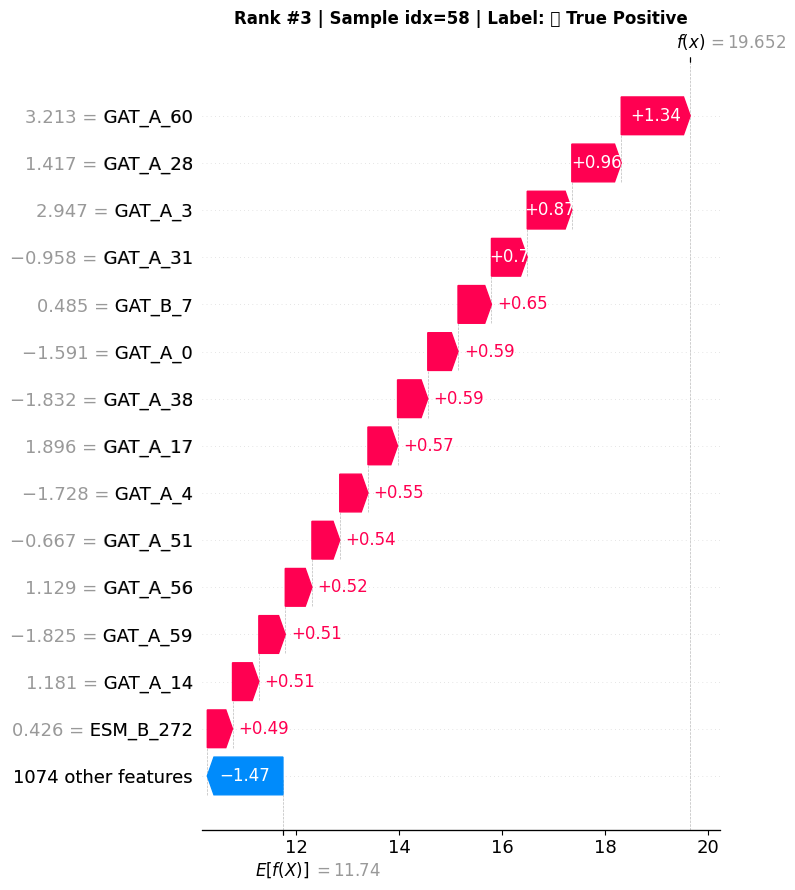

✅ Rank #3 αποθηκεύτηκε (label=1)


/tmp/ipykernel_664/2002180281.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664/2002180281.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"waterfall_rank{rank+1:02d}.png", dpi=120, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


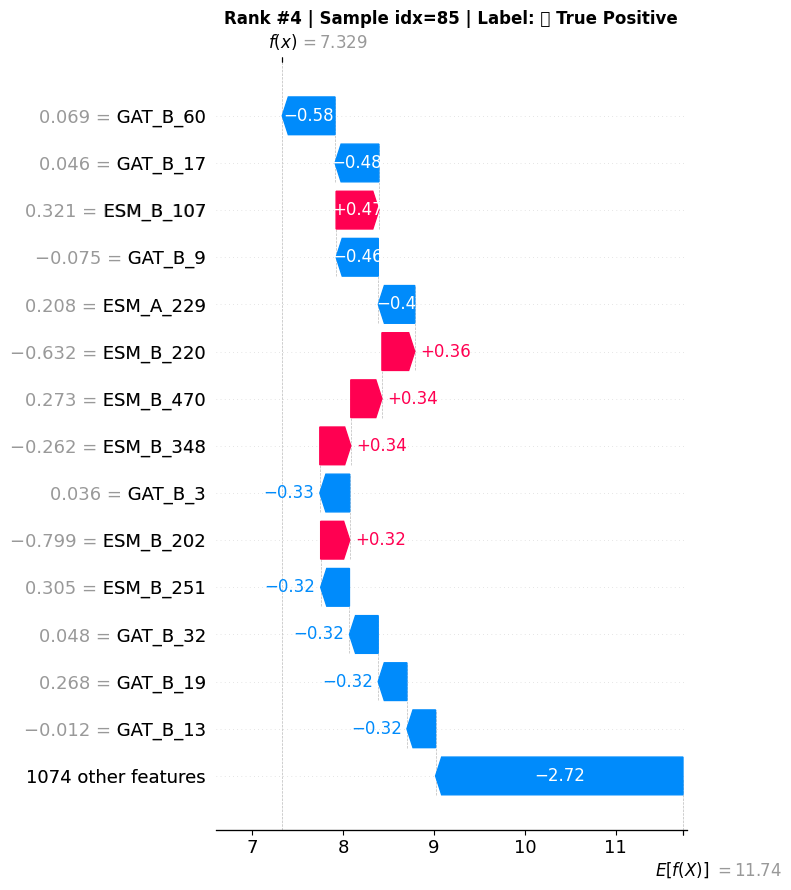

✅ Rank #4 αποθηκεύτηκε (label=1)


/tmp/ipykernel_664/2002180281.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664/2002180281.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"waterfall_rank{rank+1:02d}.png", dpi=120, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


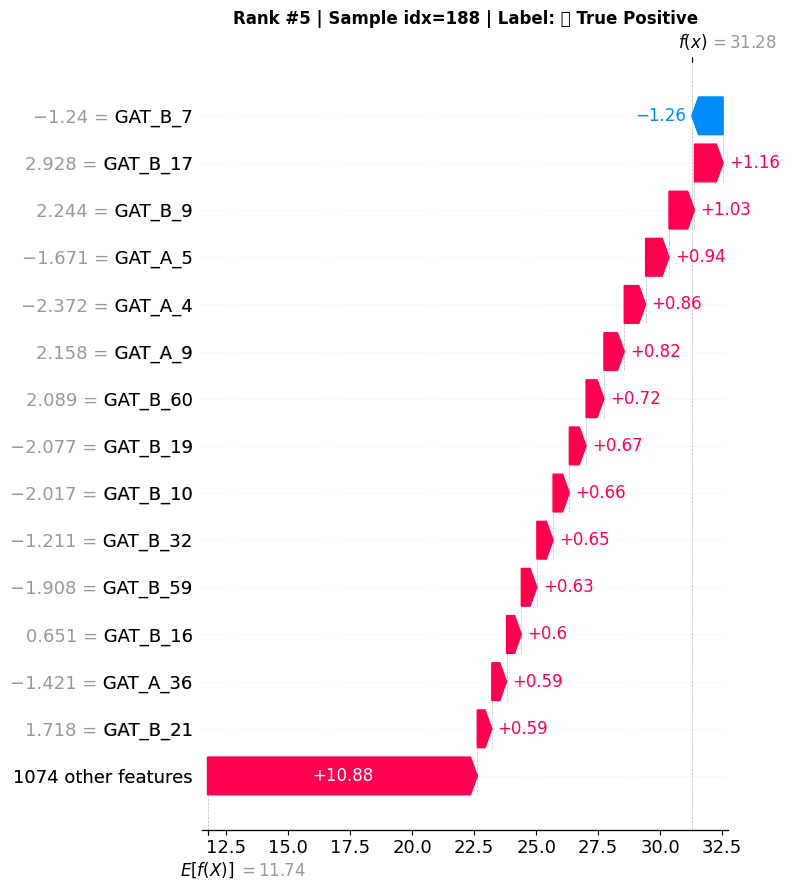

✅ Rank #5 αποθηκεύτηκε (label=1)


/tmp/ipykernel_664/2002180281.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664/2002180281.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"waterfall_rank{rank+1:02d}.png", dpi=120, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


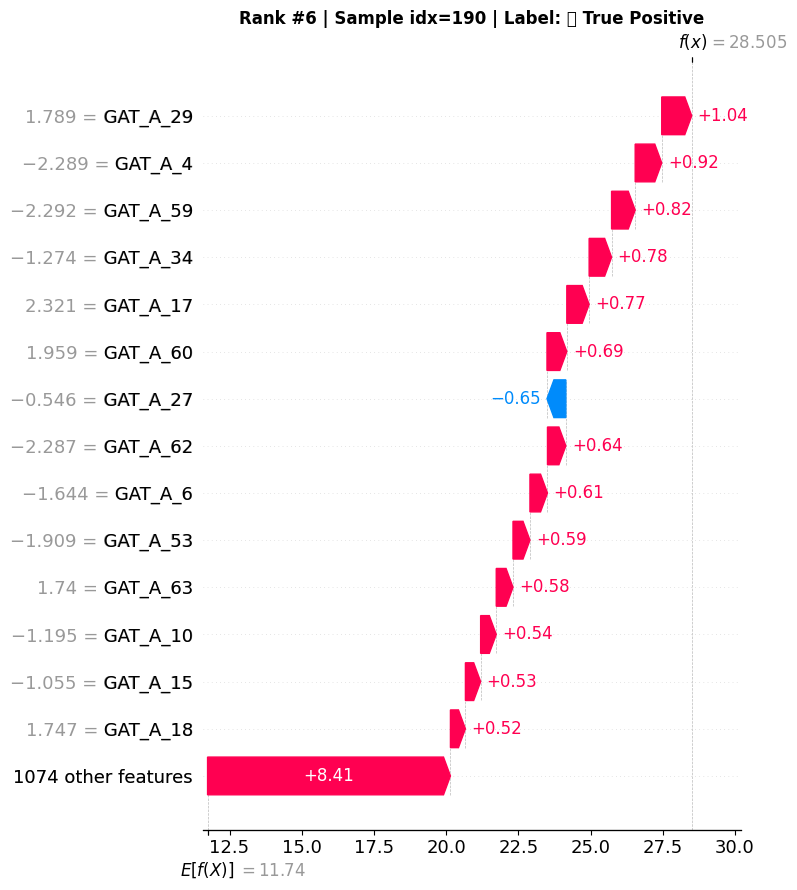

✅ Rank #6 αποθηκεύτηκε (label=1)


/tmp/ipykernel_664/2002180281.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664/2002180281.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"waterfall_rank{rank+1:02d}.png", dpi=120, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


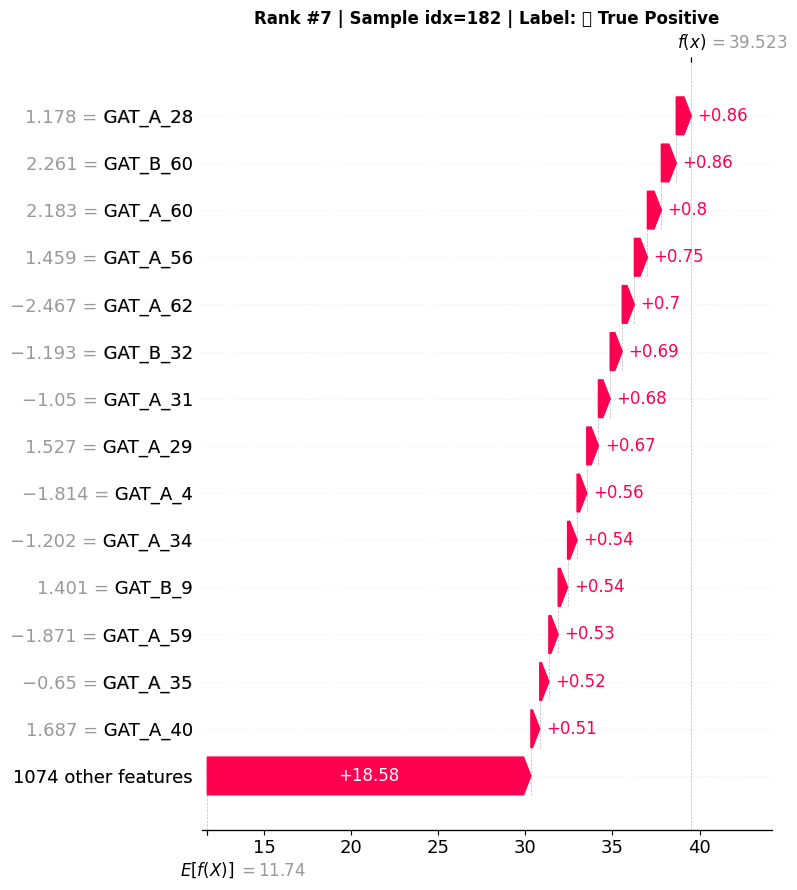

✅ Rank #7 αποθηκεύτηκε (label=1)


/tmp/ipykernel_664/2002180281.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664/2002180281.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"waterfall_rank{rank+1:02d}.png", dpi=120, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


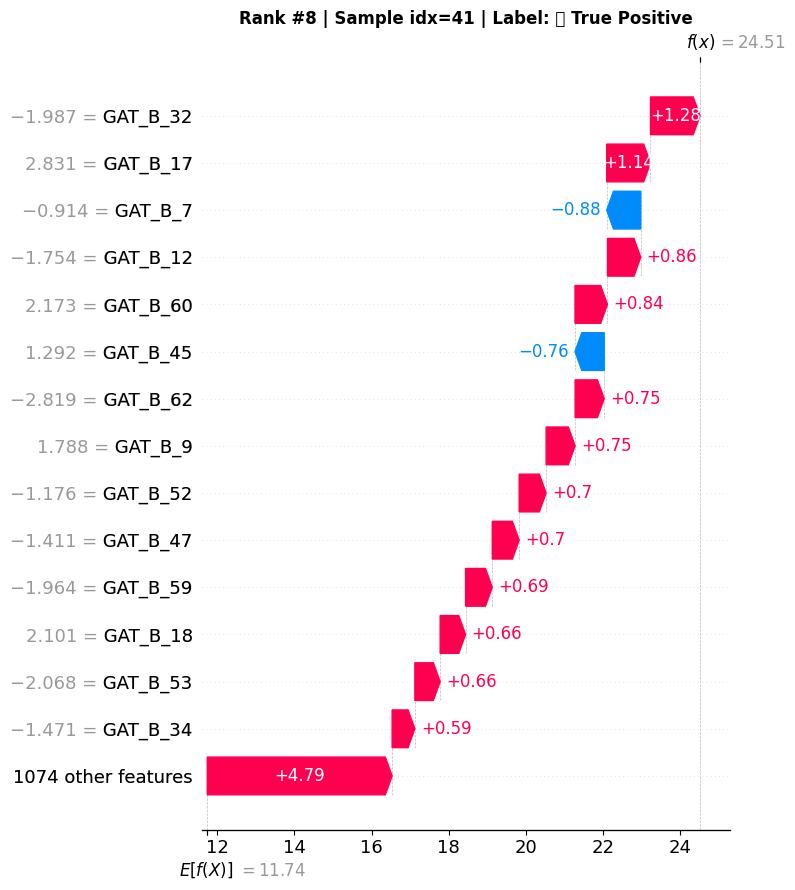

✅ Rank #8 αποθηκεύτηκε (label=1)


/tmp/ipykernel_664/2002180281.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664/2002180281.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"waterfall_rank{rank+1:02d}.png", dpi=120, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


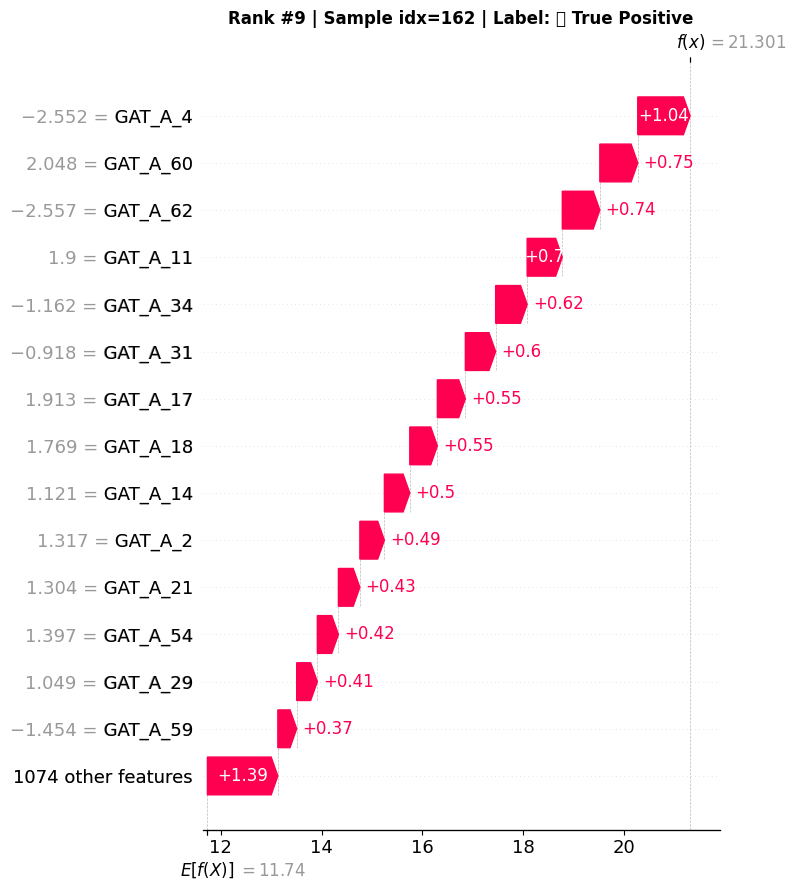

✅ Rank #9 αποθηκεύτηκε (label=1)


/tmp/ipykernel_664/2002180281.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664/2002180281.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"waterfall_rank{rank+1:02d}.png", dpi=120, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


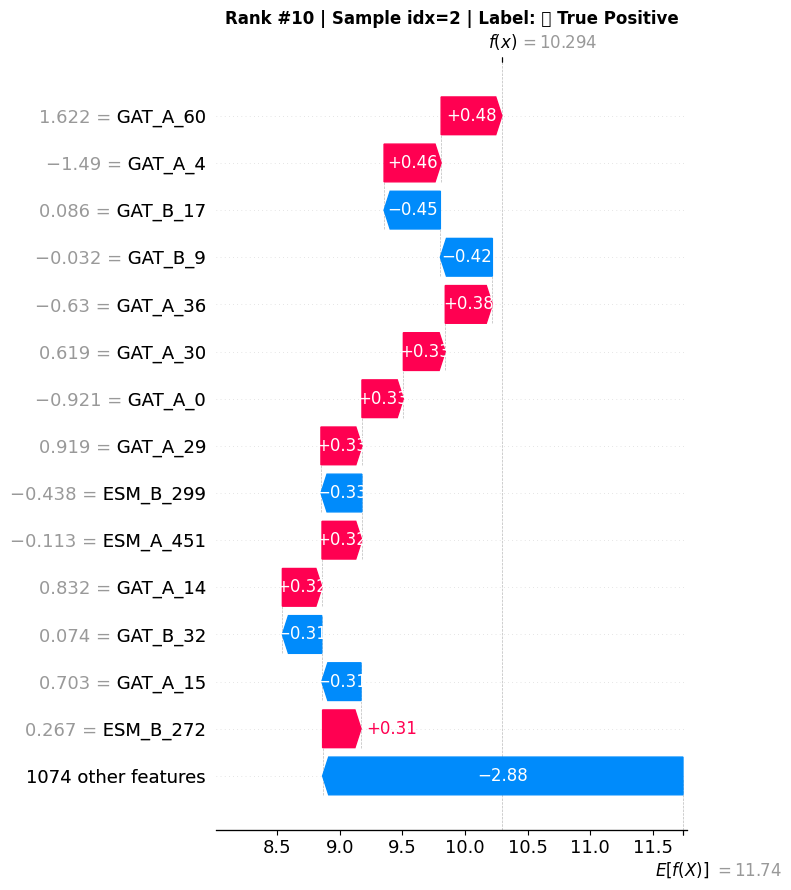

✅ Rank #10 αποθηκεύτηκε (label=1)


/tmp/ipykernel_664/2002180281.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664/2002180281.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"waterfall_rank{rank+1:02d}.png", dpi=120, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


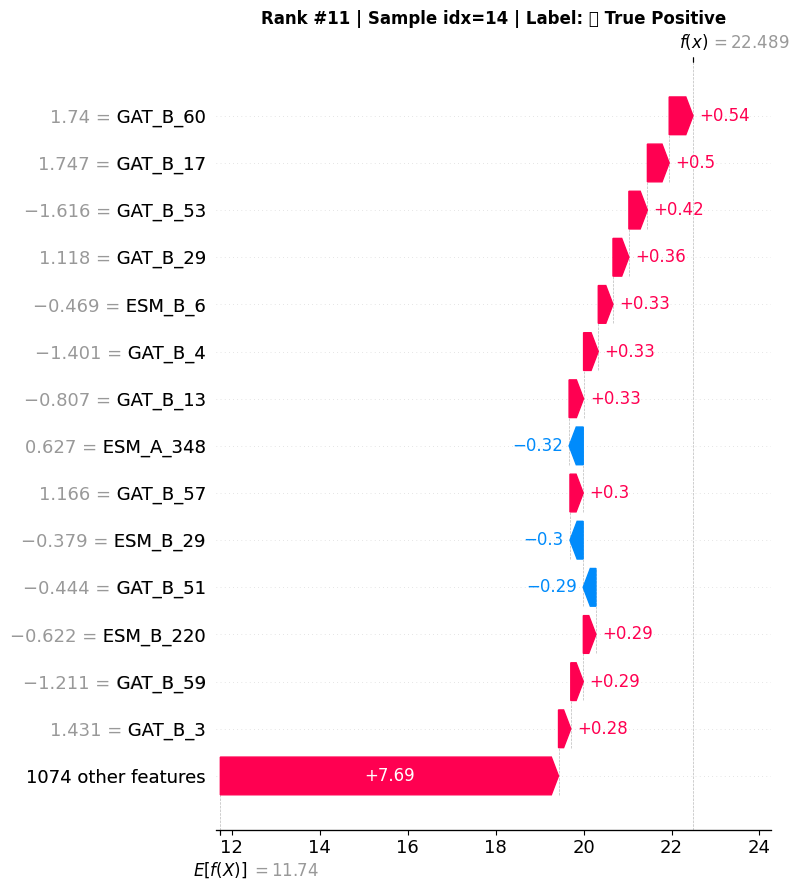

✅ Rank #11 αποθηκεύτηκε (label=1)


/tmp/ipykernel_664/2002180281.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664/2002180281.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"waterfall_rank{rank+1:02d}.png", dpi=120, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


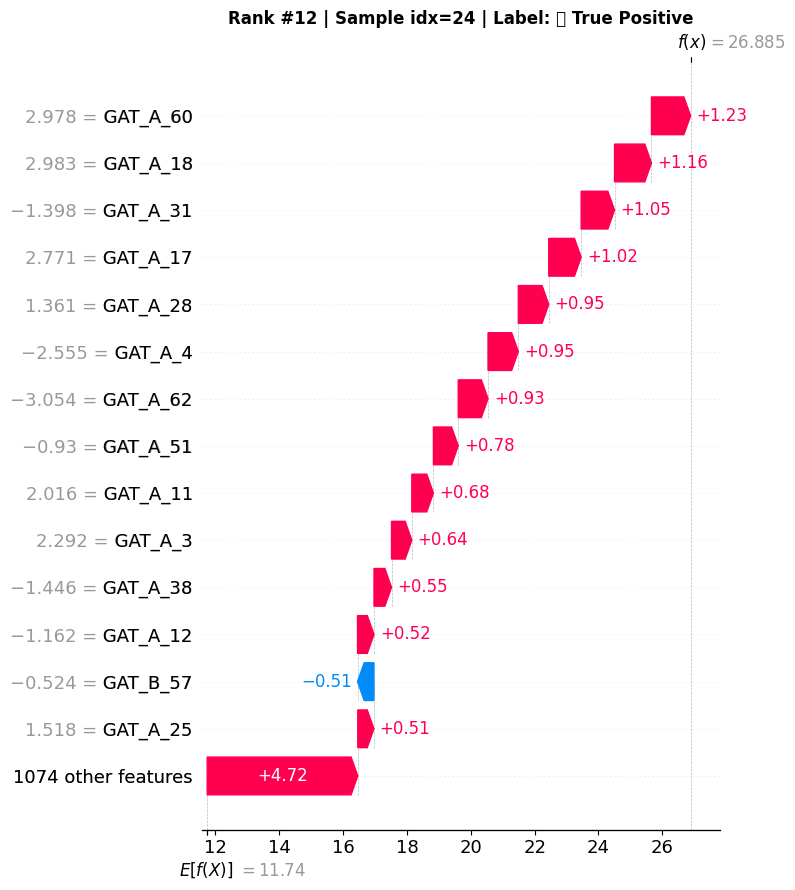

✅ Rank #12 αποθηκεύτηκε (label=1)


/tmp/ipykernel_664/2002180281.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664/2002180281.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"waterfall_rank{rank+1:02d}.png", dpi=120, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


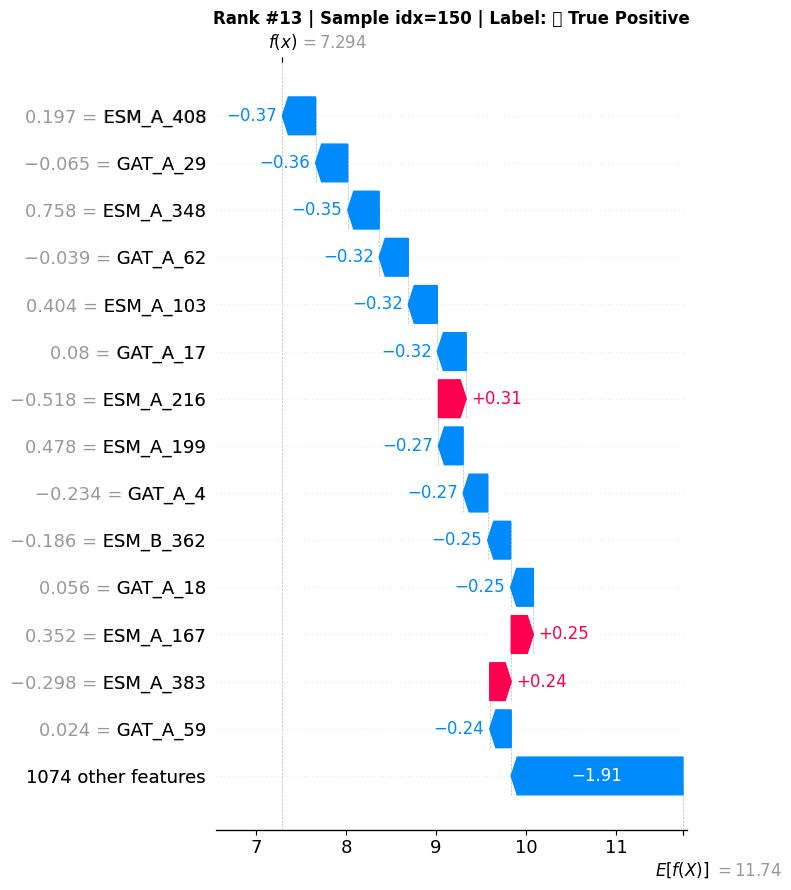

✅ Rank #13 αποθηκεύτηκε (label=1)


/tmp/ipykernel_664/2002180281.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664/2002180281.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"waterfall_rank{rank+1:02d}.png", dpi=120, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


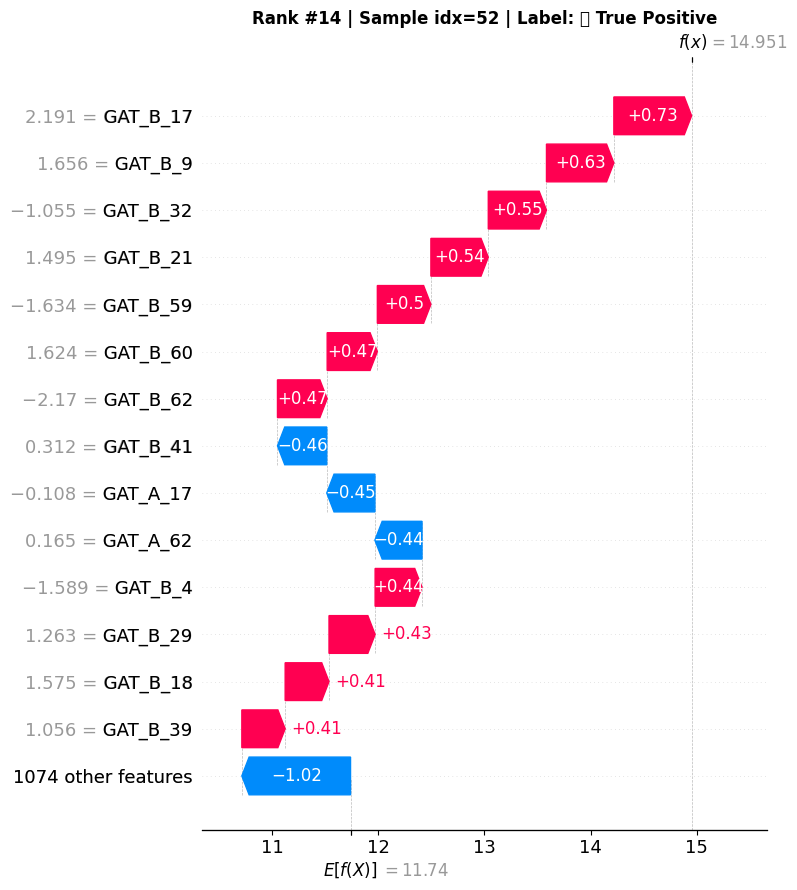

✅ Rank #14 αποθηκεύτηκε (label=1)


/tmp/ipykernel_664/2002180281.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664/2002180281.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"waterfall_rank{rank+1:02d}.png", dpi=120, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


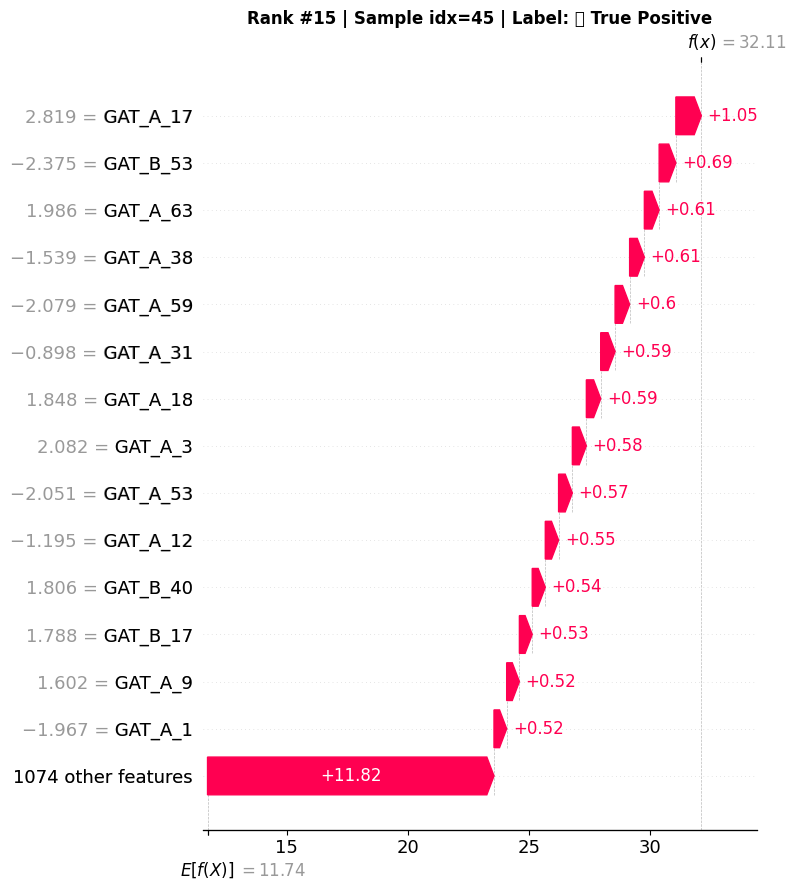

✅ Rank #15 αποθηκεύτηκε (label=1)


/tmp/ipykernel_664/2002180281.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664/2002180281.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"waterfall_rank{rank+1:02d}.png", dpi=120, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


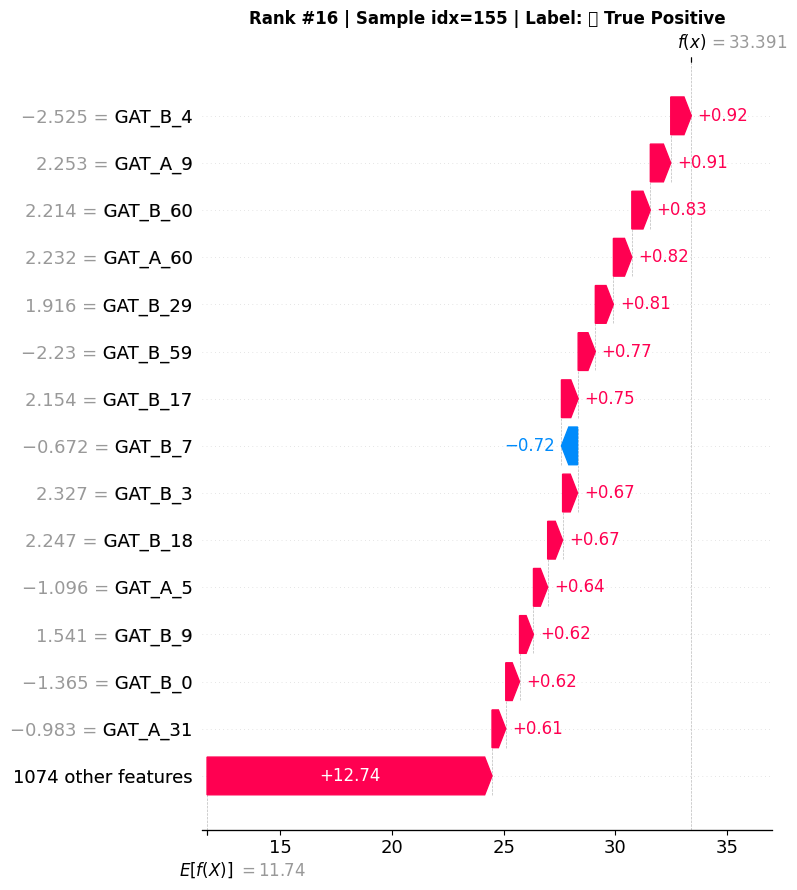

✅ Rank #16 αποθηκεύτηκε (label=1)


/tmp/ipykernel_664/2002180281.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664/2002180281.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"waterfall_rank{rank+1:02d}.png", dpi=120, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


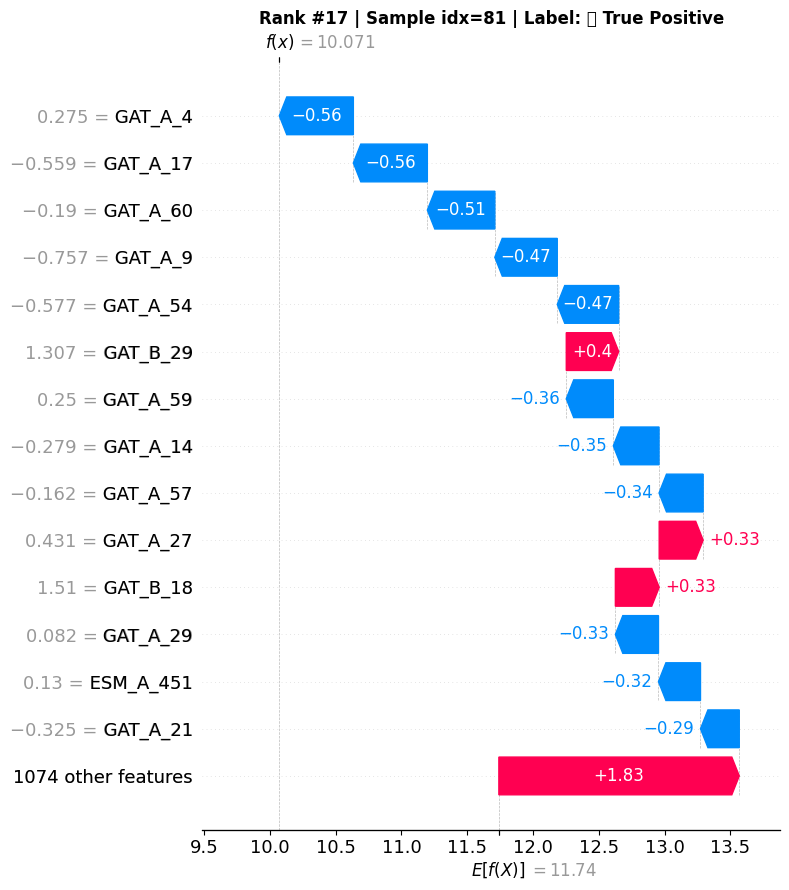

✅ Rank #17 αποθηκεύτηκε (label=1)


/tmp/ipykernel_664/2002180281.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664/2002180281.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"waterfall_rank{rank+1:02d}.png", dpi=120, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


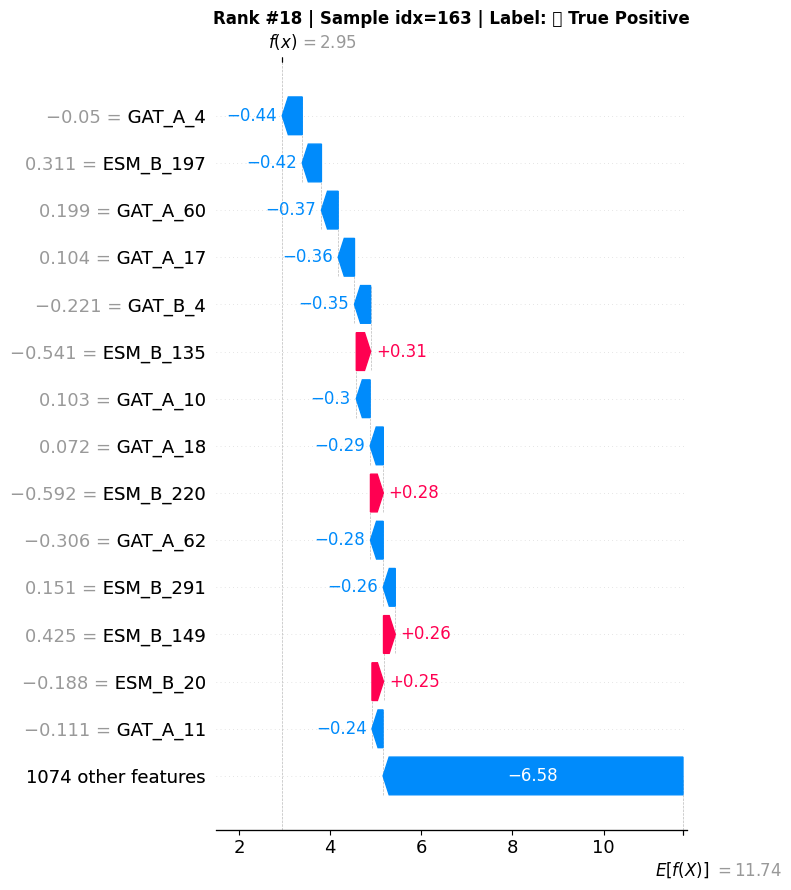

✅ Rank #18 αποθηκεύτηκε (label=1)


/tmp/ipykernel_664/2002180281.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664/2002180281.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"waterfall_rank{rank+1:02d}.png", dpi=120, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


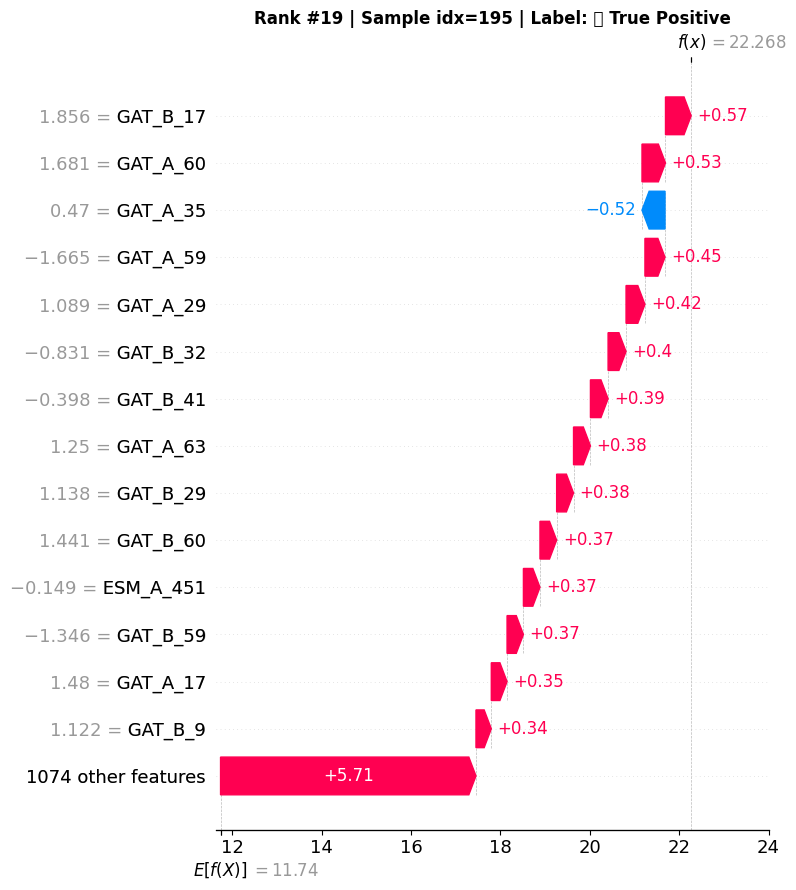

✅ Rank #19 αποθηκεύτηκε (label=1)


/tmp/ipykernel_664/2002180281.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664/2002180281.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"waterfall_rank{rank+1:02d}.png", dpi=120, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


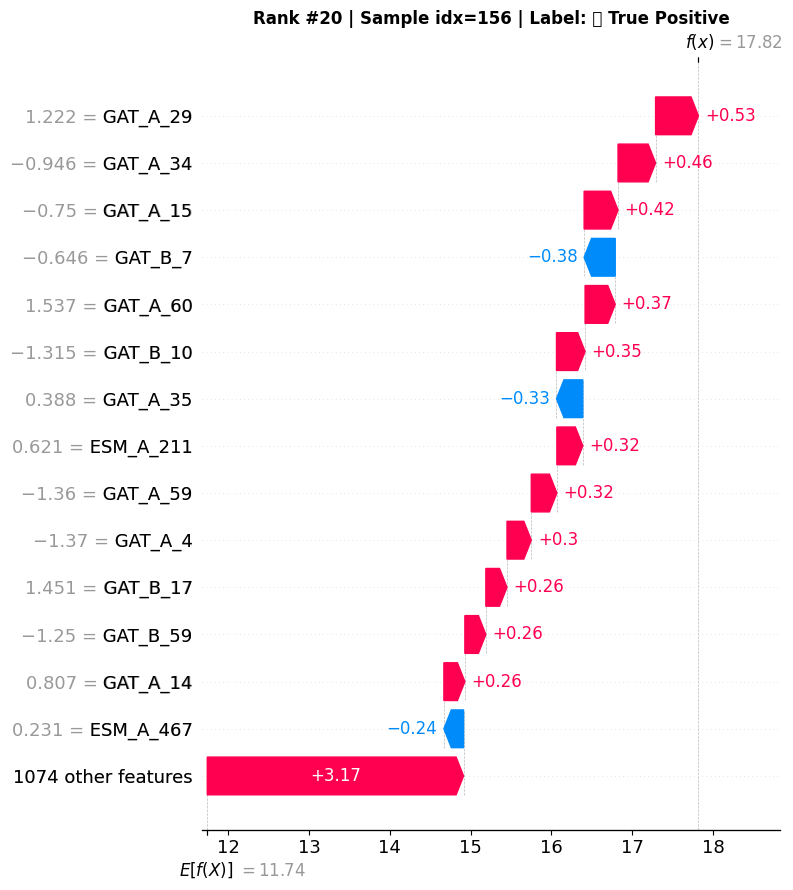

✅ Rank #20 αποθηκεύτηκε (label=1)


In [ ]:
# ============================================================
# ΚΕΛΙ 9: WATERFALL PLOTS — TOP 20 ΖΕΥΓΗ
# ============================================================
import shap
import numpy as np

y_true_np  = test_labels.cpu().numpy()
test_np    = test_sample.cpu().numpy()

# Βρίσκουμε τα top 20 ζεύγη με βάση την απόλυτη SHAP τιμή
mean_abs_shap_per_sample = np.abs(shap_arr).sum(axis=1).squeeze()
top20_indices = np.argsort(mean_abs_shap_per_sample)[::-1][:20]

# SHAP Explanation object
expected_value = explainer.expected_value
if isinstance(expected_value, list):
    expected_value = expected_value[0]

for rank, idx in enumerate(top20_indices):
    # Ensure idx is a scalar for indexing
    current_idx = int(idx) if isinstance(idx, np.ndarray) else idx

    true_label = int(y_true_np[current_idx])
    label_str  = "✅ True Positive"  if true_label == 1 else "❌ False Positive / True Negative"

    explanation = shap.Explanation(
        values         = shap_arr[current_idx].squeeze(),
        base_values    = expected_value.item(), # Fixed: Use .item() to get scalar
        data           = test_np[current_idx],
        feature_names  = feature_names
    )

    plt.figure(figsize=(14, 5))
    shap.plots.waterfall(explanation, max_display=15, show=False)
    plt.title(f"Rank #{rank+1} | Sample idx={current_idx} | Label: {label_str}",
              fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"waterfall_rank{rank+1:02d}.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"✅ Rank #{rank+1} αποθηκεύτηκε (label={true_label})")

In [ ]:
print(df_pos.head(5))
print(df_pos.columns.tolist())

                                 protein_sequences_1  \
0  MESSKKMDSPGALQTNPPLKLHTDRSAGTPVFVPEQGGYKEKFVKT...   
1  MVMSSYMVNSKYVDPKFPPCEEYLQGGYLGEQGADYYGGGAQGADF...   
2  MNRHLWKSQLCEMVQPSGGPAADQDVLGEESPLGKPAMLHLPSEQG...   
3  MAPPSTREPRVLSATSATKSDGEMVLPGFPDADSFVKFALGSVVAV...   
4  MQSGPRPPLPAPGLALALTLTMLARLASAASFFGENHLEVPVATAL...   

                                 protein_sequences_2  
0  MARPHPWWLCVLGTLVGLSATPAPKSCPERHYWAQGKLCCQMCEPG...  
1  MAENVVEPGPPSAKRPKLSSPALSASASDGTDFGSLFDLEHDLPDE...  
2  MEGGRRARVVIESKRNFFLGAFPTPFPAEHVELGRLGDSETAMVPG...  
3  MLFYSFFKSLVGKDVVVELKNDLSICGTLHSVDQYLNIKLTDISVT...  
4  MQTIKCVVVGDGAVGKTCLLISYTTNKFPSEYVPTVFDNYAVTVMI...  
['protein_sequences_1', 'protein_sequences_2']


In [ ]:
# ============================================================
# ΚΕΛΙ 10: ΕΞΑΓΩΓΗ ΑΛΛΗΛΟΥΧΙΩΝ TOP 20 ΖΕΥΓΩΝ
# ============================================================

# Αντίστροφο λεξικό: idx → όνομα πρωτεΐνης
idx_to_protein = {v: k for k, v in protein_to_idx.items()}

print("=" * 70)
print("TOP 20 ΖΕΥΓΗ — ΑΛΛΗΛΟΥΧΙΕΣ ΓΙΑ UNIPROT BLAST")
print("=" * 70)

top20_pairs_info = []

for rank, idx in enumerate(top20_indices):
    # Βρίσκουμε τους κόμβους του ζεύγους
    node_A = test_edge_label_index[0][idx].item()
    node_B = test_edge_label_index[1][idx].item()

    seq_A  = idx_to_protein[node_A]
    seq_B  = idx_to_protein[node_B]

    true_label = int(y_true_np[idx])
    label_str  = "PPI" if true_label == 1 else "No PPI"

    top20_pairs_info.append({
        "Rank"      : rank + 1,
        "Label"     : label_str,
        "Seq_A_50"  : seq_A[:50],  # Πρώτοι 50 χαρακτήρες για preview
        "Seq_B_50"  : seq_B[:50],
        "Full_Seq_A": seq_A,
        "Full_Seq_B": seq_B,
    })

    print(f"\n📌 Rank #{rank+1} | Label: {label_str}")
    print(f"   Πρωτεΐνη Α: {seq_A[:60]}...")
    print(f"   Πρωτεΐνη Β: {seq_B[:60]}...")

# Αποθήκευση σε CSV για εύκολη χρήση
df_top20 = pd.DataFrame(top20_pairs_info)
df_top20.to_csv("top20_pairs.csv", index=False)
print("\n✅ Αποθηκεύτηκε: top20_pairs.csv")

TOP 20 ΖΕΥΓΗ — ΑΛΛΗΛΟΥΧΙΕΣ ΓΙΑ UNIPROT BLAST

📌 Rank #1 | Label: PPI
   Πρωτεΐνη Α: MAPRKRGGRGISFIFCCFRNNDHPEITYRLRNDSNFALQTMEPALPMPPVEELDVMFSEL...
   Πρωτεΐνη Β: MAETKIIYHMDEEETPYLVKLPVAPERVTLADFKNVLSNRPVHAYKFFFKSMDQDFGVVK...

📌 Rank #2 | Label: PPI
   Πρωτεΐνη Α: MGKLRRRYNIKGRQQAGPGPSKGPPEPPPVQLELEDKDTLKGVDASNALVLPGKKKKKTK...
   Πρωτεΐνη Β: MEQRRPWPRALEVDSRSVVLLSVVWVLLAPPAAGMPQFSTFHSENRDWTFNHLTVHQGTG...

📌 Rank #3 | Label: PPI
   Πρωτεΐνη Α: MDGSGERSLPEPGSQSSAASDDIEIVVNVGGVRQVLYGDLLSQYPETRLAELINCLAGGY...
   Πρωτεΐνη Β: MTMAGGRRGLVAPQNTFLENIVRRSNDTNFVLGNAQIVDWPIVYSNDGFCKLSGYHRAEV...

📌 Rank #4 | Label: PPI
   Πρωτεΐνη Α: MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQWFTEDPGP...
   Πρωτεΐνη Β: MSAQSVEEDSILIIPTPDEEEKILRVKLEEDPDGEEGSSIPWNHLPDPEIFRQRFRQFGY...

📌 Rank #5 | Label: PPI
   Πρωτεΐνη Α: MAVARAALGPLVTGLYDVQAFKFGDFVLKSGLSSPIYIDLRGIVSRPRLLSQVADILFQT...
   Πρωτεΐνη Β: MPAKTPIYLKAANNKKGKKFKLRDILSPDMISPPLGDFRHTIHIGKEGQHDVFGDISFLQ...

📌 Rank #6 | Label: PPI
   Πρωτεΐνη Α: MPPRAP

In [ ]:
# ============================================================
# ΚΕΛΙ 11: ΕΞΑΓΩΓΗ ΠΛΗΡΩΝ ΑΛΛΗΛΟΥΧΙΩΝ ΓΙΑ UNIPROT BLAST
# ============================================================

for rank, info in enumerate(top20_pairs_info):
    print(f"\n{'='*60}")
    print(f"RANK #{info['Rank']} | {info['Label']}")
    print(f"{'='*60}")
    print(f"--- ΠΡΩΤΕΪΝΗ Α ---")
    print(info['Full_Seq_A'])
    print(f"\n--- ΠΡΩΤΕΪΝΗ Β ---")
    print(info['Full_Seq_B'])


RANK #1 | PPI
--- ΠΡΩΤΕΪΝΗ Α ---
MAPRKRGGRGISFIFCCFRNNDHPEITYRLRNDSNFALQTMEPALPMPPVEELDVMFSELVDELDLTDKHREAMFALPAEKKWQIYCSKKKDQEENKGATSWPEFYIDQLNSMAARKSLLALEKEEEEERSKTIESLKTALRTKPMRFVTRFIDLDGLSCILNFLKTMDYETSESRIHTSLIGCIKALMNNSQGRAHVLAHSESINVIAQSLSTENIKTKVAVLEILGAVCLVPGGHKKVLQAMLHYQKYASERTRFQTLINDLDKSTGRYRDEVSLKTAIMSFINAVLSQGAGVESLDFRLHLRYEFLMLGIQPVIDKLREHENSTLDRHLDFFEMLRNEDELEFAKRFELVHIDTKSATQMFELTRKRLTHSEAYPHFMSILHHCLQMPYKRSGNTVQYWLLLDRIIQQIVIQNDKGQDPDSTPLENFNIKNVVRMLVNENEVKQWKEQAEKMRKEHNELQQKLEKKERECDAKTQEKEEMMQTLNKMKEKLEKETTEHKQVKQQVADLTAQLHELSRRAVCASIPGGPSPGAPGGPFPSSVPGSLLPPPPPPPLPGGMLPPPPPPLPPGGPPPPPGPPPLGAIMPPPGAPMGLALKKKSIPQPTNALKSFNWSKLPENKLEGTVWTEIDDTKVFKILDLEDLERTFSAYQRQQDFFVNSNSKQKEADAIDDTLSSKLKVKELSVIDGRRAQNCNILLSRLKLSNDEIKRAILTMDEQEDLPKDMLEQLLKFVPEKSDIDLLEEHKHELDRMAKADRFLFEMSRINHYQQRLQSLYFKKKFAERVAEVKPKVEAIRSGSEEVFRSGALKQLLEVVLAFGNYMNKGQRGNAYGFKISSLNKIADTKSSIDKNITLLHYLITIVENKYPSVLNLNEELRDIPQAAKVNMTELDKEISTLRSGLKAVETELEYQKSQPPQPGDKFVSVVSQFITVASFSFSDVEDLLAEAKDLFTKAVKHFGEEAGK

In [ ]:
# ============================================================
# ΚΕΛΙ 11c: NCBI BLAST API → UniProt ID → STRING Score
# ============================================================
import requests
import time
import pandas as pd
from xml.etree import ElementTree as ET

def ncbi_blast(sequence, max_wait=120):
    """Στέλνει αλληλουχία στο NCBI BLAST και επιστρέφει top hit."""

    # Βήμα 1: Submit job
    submit_url = "https://blast.ncbi.nlm.nih.gov/blast/Blast.cgi"
    params = {
        "CMD"       : "Put",
        "PROGRAM"   : "blastp",
        "DATABASE"  : "swissprot",
        "QUERY"     : sequence,
        "FORMAT_TYPE": "XML",
        "HITLIST_SIZE": 1,
        "FILTER"    : "F",
        "EXPECT"    : "0.001",
    }
    r = requests.post(submit_url, data=params)

    # Παίρνουμε το RID (Request ID)
    rid = None
    for line in r.text.split("\n"):
        if "RID = " in line:
            rid = line.split("RID = ")[1].strip()
            break

    if not rid:
        return None, None, None

    print(f"      RID: {rid} — Περιμένω αποτέλεσμα...", end="")

    # Βήμα 2: Poll για αποτέλεσμα
    for _ in range(max_wait // 10):
        time.sleep(10)
        print(".", end="", flush=True)

        check_params = {
            "CMD"        : "Get",
            "RID"        : rid,
            "FORMAT_TYPE": "XML",
            "HITLIST_SIZE": 1,
        }
        r2 = requests.get(submit_url, params=check_params)

        if "Status=WAITING" in r2.text:
            continue
        if "Status=FAILED" in r2.text:
            return None, None, None

        # Parse XML
        try:
            root = ET.fromstring(r2.text)
            ns   = ""
            hits = root.findall(".//Hit")
            if hits:
                hit      = hits[0]
                hit_id   = hit.findtext("Hit_accession", "")
                hit_def  = hit.findtext("Hit_def", "")
                identity = hit.find(".//Hsp_identity")
                length   = hit.find(".//Hsp_align-len")
                pct      = int(identity.text)/int(length.text)*100 if identity is not None else 0
                print(f" ✅")
                return hit_id, hit_def.split(" OS=")[0][:50], round(pct, 1)
        except:
            pass

    print(" ⏱️ Timeout")
    return None, None, None

def get_string_score_by_id(uniprot_A, uniprot_B):
    """Παίρνει STRING score με UniProt IDs."""
    def to_string_id(uid):
        r = requests.post(
            "https://string-db.org/api/json/get_string_ids",
            data={"identifier": uid, "species": "9606",
                  "limit": 1, "caller_identity": "thesis_ppi"},
            timeout=20
        )
        d = r.json()
        return (d[0].get("stringId"), d[0].get("preferredName")) if d else (None, None)

    sid_A, name_A = to_string_id(uniprot_A); time.sleep(0.5)
    sid_B, name_B = to_string_id(uniprot_B); time.sleep(0.5)

    if not sid_A or not sid_B:
        return name_A, name_B, 0

    r = requests.post(
        "https://string-db.org/api/json/interaction_partners",
        data={"identifiers": f"{sid_A}%0d{sid_B}", "species": "9606",
              "required_score": 0, "caller_identity": "thesis_ppi"},
        timeout=20
    )
    for item in r.json():
        if sid_B in {item.get("stringId_A"), item.get("stringId_B")}:
            return name_A, name_B, item.get("score", 0)
    return name_A, name_B, 0

# ── Κύρια Εκτέλεση ───────────────────────────────────────────
print("=" * 65)
print("   NCBI BLAST → STRING — ΒΙΟΛΟΓΙΚΗ ΕΠΑΛΗΘΕΥΣΗ TOP 20")
print("=" * 65)
print("⚠️  Κάθε BLAST παίρνει ~30-60 δευτερόλεπτα. Συνολικά ~20 λεπτά.\n")

results_bio = []

for info in top20_pairs_info:
    rank = info["Rank"]
    print(f"\n{'─'*50}")
    print(f"📌 Rank #{rank:02d} | {info['Label']}")

    # BLAST Πρωτεΐνη Α
    print(f"   🔍 BLAST Α...")
    uid_A, name_A, pct_A = ncbi_blast(info["Full_Seq_A"])
    time.sleep(3)

    # BLAST Πρωτεΐνη Β
    print(f"   🔍 BLAST Β...")
    uid_B, name_B, pct_B = ncbi_blast(info["Full_Seq_B"])
    time.sleep(3)

    print(f"   Α: {name_A} ({uid_A}) — {pct_A}% identity")
    print(f"   Β: {name_B} ({uid_B}) — {pct_B}% identity")

    # STRING Score
    string_name_A, string_name_B, score = 0, 0, 0
    if uid_A and uid_B:
        string_name_A, string_name_B, score = get_string_score_by_id(uid_A, uid_B)
        time.sleep(1)

    if   score >= 0.7: verified = "✅ High Confidence"
    elif score >= 0.4: verified = "🟡 Medium Confidence"
    elif score >  0:   verified = "🟠 Low Confidence"
    else:              verified = "❌ No Interaction"

    print(f"   STRING: {score:.3f} → {verified}")

    results_bio.append({
        "Rank"        : rank,
        "Label"       : info["Label"],
        "Protein_A"   : name_A or "NOT FOUND",
        "UniProt_A"   : uid_A,
        "Identity_A"  : f"{pct_A}%",
        "Protein_B"   : name_B or "NOT FOUND",
        "UniProt_B"   : uid_B,
        "Identity_B"  : f"{pct_B}%",
        "STRING_Score": round(score, 3),
        "Verified"    : verified
    })

# ── Τελικός Πίνακας ──────────────────────────────────────────
df_bio = pd.DataFrame(results_bio)
print("\n\n" + "=" * 65)
print("📊 ΤΕΛΙΚΟΣ ΠΙΝΑΚΑΣ ΒΙΟΛΟΓΙΚΗΣ ΕΠΑΛΗΘΕΥΣΗΣ:")
print("=" * 65)
print(df_bio[["Rank","Protein_A","Protein_B","STRING_Score","Verified"]].to_string(index=False))

verified = df_bio["Verified"].str.contains("✅|🟡").sum()
print(f"\n📌 Επαληθευμένα (≥0.4): {verified}/20 ({verified/20*100:.1f}%)")

df_bio.to_csv("biological_validation.csv", index=False)
print("✅ Αποθηκεύτηκε: biological_validation.csv")

   NCBI BLAST → STRING — ΒΙΟΛΟΓΙΚΗ ΕΠΑΛΗΘΕΥΣΗ TOP 20
⚠️  Κάθε BLAST παίρνει ~30-60 δευτερόλεπτα. Συνολικά ~20 λεπτά.


──────────────────────────────────────────────────
📌 Rank #01 | PPI
   🔍 BLAST Α...
      RID: YECGWUR2016 — Περιμένω αποτέλεσμα.... ✅
   🔍 BLAST Β...
      RID: YECHB6U1016 — Περιμένω αποτέλεσμα...... ✅
   Α: RecName: Full=Disheveled-associated activator of m (Q9Y4D1) — 100.0% identity
   Β: RecName: Full=Segment polarity protein dishevelled (Q5IS48) — 99.9% identity
   STRING: 0.000 → ❌ No Interaction

──────────────────────────────────────────────────
📌 Rank #02 | PPI
   🔍 BLAST Α...
      RID: YECJHE7T016 — Περιμένω αποτέλεσμα........ ✅
   🔍 BLAST Β...
      RID: YECM9233014 — Περιμένω αποτέλεσμα..... ✅
   Α: RecName: Full=Probable ATP-dependent RNA helicase  (Q8IY37) — 100.0% identity
   Β: RecName: Full=Plexin-A2; AltName: Full=Semaphorin  (O75051) — 100.0% identity
   STRING: 0.270 → 🟠 Low Confidence

──────────────────────────────────────────────────
📌 Rank #03

In [ ]:
# ============================================================
# ΚΕΛΙ 12: GAT ATTENTION WEIGHTS — ΕΞΑΓΩΓΗ
# ============================================================
import torch
import torch.nn as nn
from torch_geometric.nn import GATConv

# Φτιάχνουμε νέο GAT που επιστρέφει attention weights
class GATWithAttention(nn.Module):
    def __init__(self, num_nodes, embedding_dim=64, hidden_channels=64, heads=4):
        super().__init__()
        self.node_emb = nn.Embedding(num_nodes, embedding_dim)
        self.conv1 = GATConv(embedding_dim, hidden_channels,
                             heads=heads, dropout=0.3)
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels,
                             heads=1, concat=False, dropout=0.3)

    def encode_with_attention(self, x, edge_index):
        x = self.node_emb.weight
        # Παίρνουμε attention από LAYER 1
        x1, (edge_idx1, att1) = self.conv1(
            x, edge_index, return_attention_weights=True
        )
        x1 = x1.relu()
        # Παίρνουμε attention από LAYER 2
        x2, (edge_idx2, att2) = self.conv2(
            x1, edge_index, return_attention_weights=True
        )
        return x2, edge_idx1, att1, edge_idx2, att2

# Αντιγράφουμε τα βάρη από το εκπαιδευμένο μοντέλο
attn_model = GATWithAttention(num_nodes).to(device)
attn_model.load_state_dict(model.state_dict())
attn_model.eval()

with torch.no_grad():
    gat_out, e_idx1, att1, e_idx2, att2 = attn_model.encode_with_attention(
        data.x, data.edge_index
    )

print(f"✅ Layer 1 attention: {att1.shape}")  # [num_edges, heads]
print(f"✅ Layer 2 attention: {att2.shape}")  # [num_edges, 1]

# Χρησιμοποιούμε το Layer 2 (τελικό) — mean across heads αν χρειαστεί
att_final = att2.squeeze(-1)  # [num_edges]
print(f"✅ Final attention weights: {att_final.shape}")

✅ Layer 1 attention: torch.Size([39648, 4])
✅ Layer 2 attention: torch.Size([39648, 1])
✅ Final attention weights: torch.Size([39648])


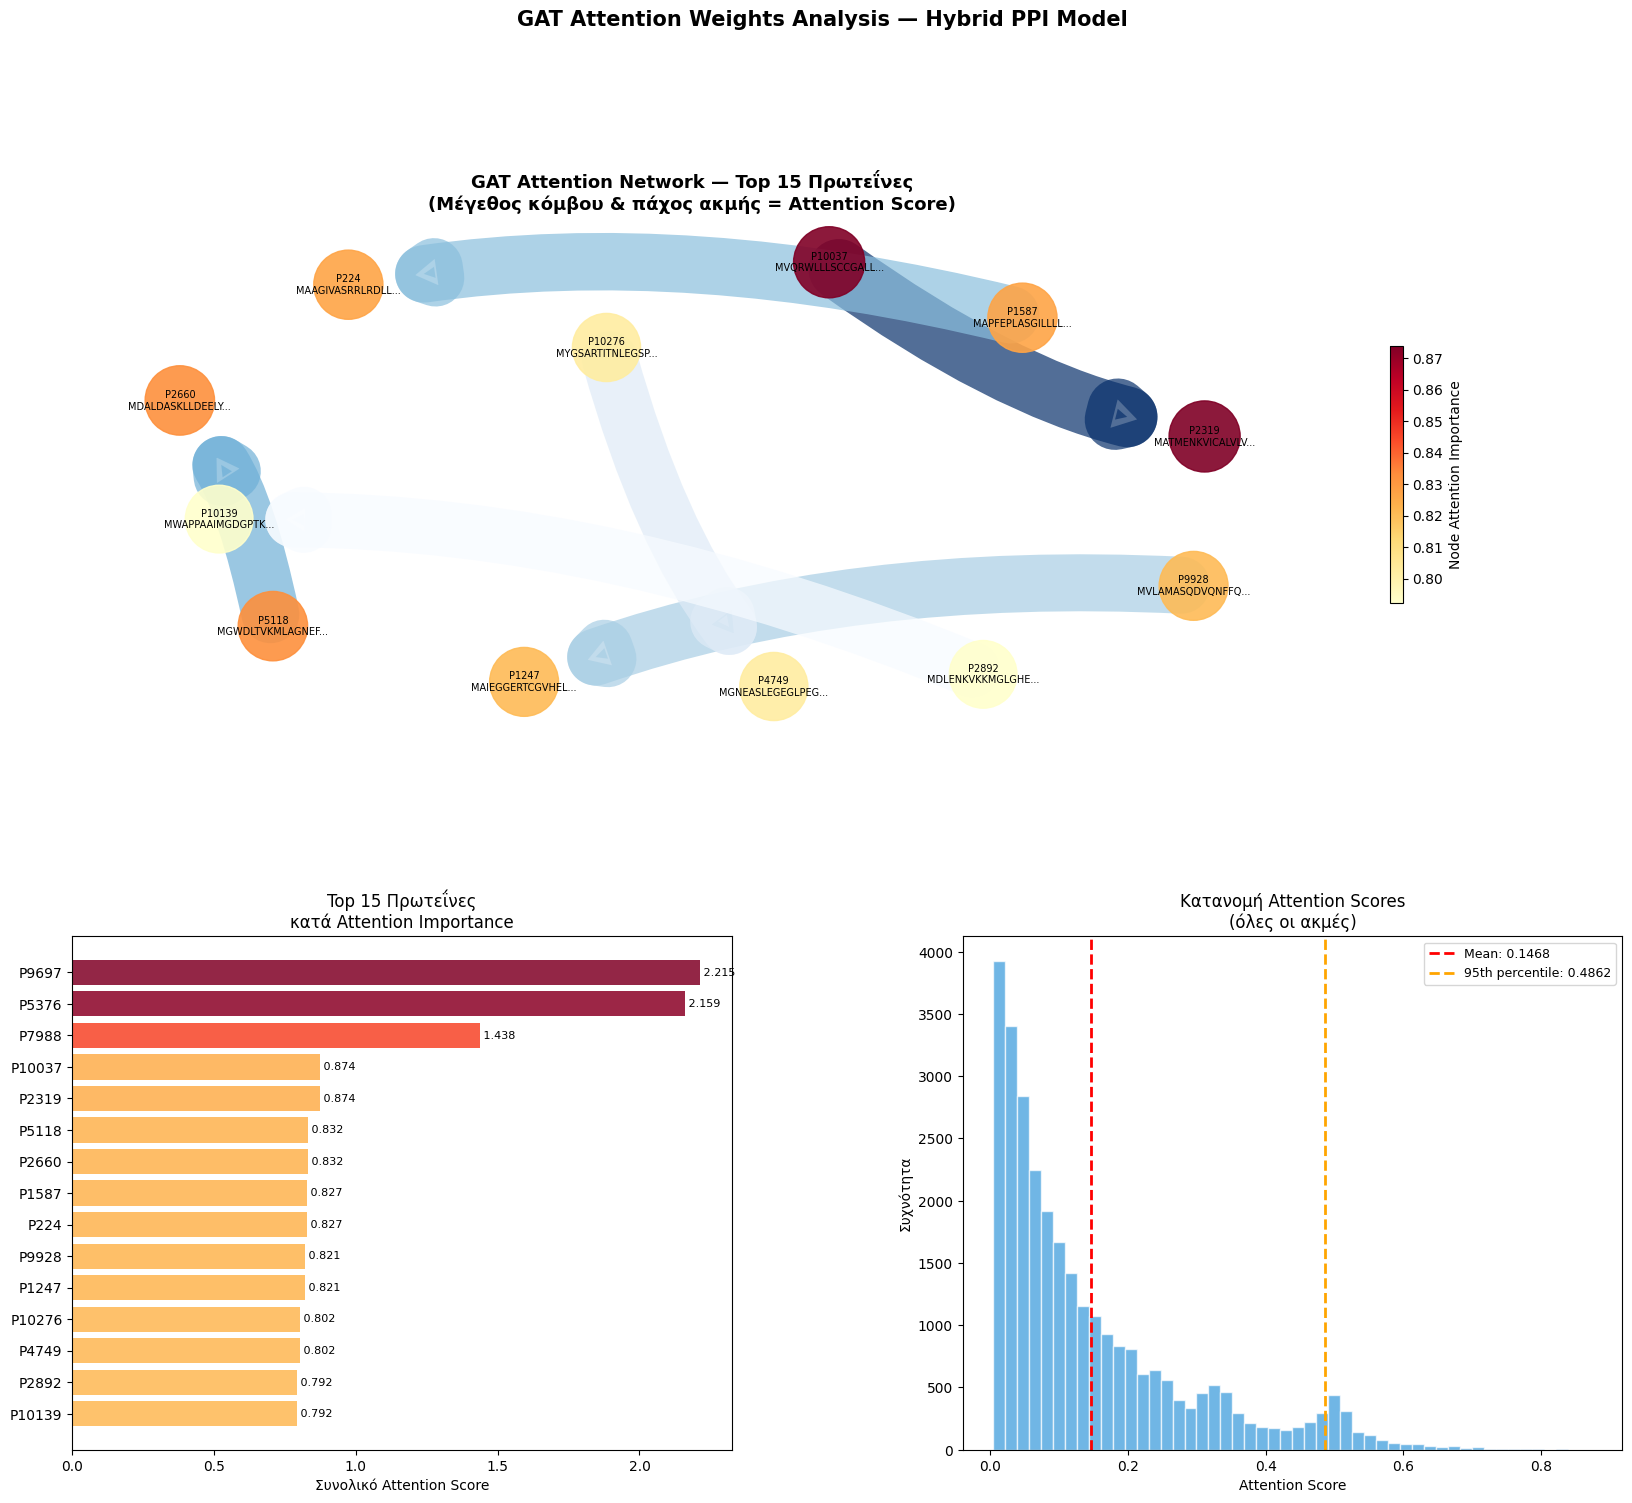

✅ Αποθηκεύτηκε: attention_analysis.png


In [ ]:
# ============================================================
# ΚΕΛΙ 15: ATTENTION WEIGHTS — ΟΠΤΙΚΟΠΟΙΗΣΗ ΓΙΑ ΔΙΠΛΩΜΑΤΙΚΗ
# ============================================================
!pip install matplotlib networkx -q

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import numpy as np

# ── Προετοιμασία δεδομένων ───────────────────────────────────
# Παίρνουμε τα top-50 edges με υψηλότερο attention (χωρίς self-loops)
att_scores_np = att2.squeeze(-1).cpu().numpy()
edge_src_np   = e_idx2[0].cpu().numpy()
edge_dst_np   = e_idx2[1].cpu().numpy()

# Φιλτράρουμε self-loops
mask     = edge_src_np != edge_dst_np
att_filt = att_scores_np[mask]
src_filt = edge_src_np[mask]
dst_filt = edge_dst_np[mask]

# Top 50 edges
top50_idx = np.argsort(att_filt)[::-1][:50]
top_src   = src_filt[top50_idx]
top_dst   = dst_filt[top50_idx]
top_att   = att_filt[top50_idx]

# Βρίσκουμε τους πιο "σημαντικούς" κόμβους
from collections import Counter
node_importance = Counter()
for s, d, a in zip(top_src, top_dst, top_att):
    node_importance[s] += a
    node_importance[d] += a

top15_nodes = [n for n, _ in node_importance.most_common(15)]

# ── Γράφημα 1: Attention Network Graph ──────────────────────
fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])  # Πλήρης πρώτη γραμμή

G = nx.DiGraph()
for s, d, a in zip(top_src, top_dst, top_att):
    if s in top15_nodes and d in top15_nodes:
        G.add_edge(s, d, weight=float(a))

# Layout
pos = nx.spring_layout(G, seed=42, k=2)

# Node sizes ανάλογα με σημασία
node_sizes  = [node_importance[n] * 3000 for n in G.nodes()]
node_colors = [node_importance[n] for n in G.nodes()]

# Edge widths ανάλογα με attention
edges      = G.edges(data=True)
edge_widths = [d["weight"] * 50 for _, _, d in edges]
edge_colors = [d["weight"] for _, _, d in edges]

# Draw
nx.draw_networkx_nodes(G, pos, ax=ax1,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.YlOrRd, alpha=0.9)

nx.draw_networkx_edges(G, pos, ax=ax1,
    width=edge_widths,
    edge_color=edge_colors,
    edge_cmap=plt.cm.Blues,
    alpha=0.7,
    arrows=True,
    arrowsize=20,
    connectionstyle="arc3,rad=0.1")

# Labels — πρώτοι 20 χαρακτήρες της αλληλουχίας
labels = {n: f"P{n}\n{idx_to_protein[n][:15]}..." for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, ax=ax1, font_size=7)

ax1.set_title("GAT Attention Network — Top 15 Πρωτεΐνες\n"
              "(Μέγεθος κόμβου & πάχος ακμής = Attention Score)",
              fontsize=13, fontweight="bold")
ax1.axis("off")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd,
     norm=plt.Normalize(min(node_colors), max(node_colors)))
sm.set_array([])
plt.colorbar(sm, ax=ax1, label="Node Attention Importance", shrink=0.5)

# ── Γράφημα 2: Top 15 Κόμβοι Bar Chart ─────────────────────
ax2 = fig.add_subplot(gs[1, 0])

top15_scores = [node_importance[n] for n in top15_nodes]
top15_labels = [f"P{n}" for n in top15_nodes]
colors_bar   = plt.cm.YlOrRd(
    np.array(top15_scores) / max(top15_scores))

bars = ax2.barh(top15_labels[::-1], top15_scores[::-1],
                color=colors_bar[::-1], alpha=0.85)
for bar in bars:
    ax2.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f" {bar.get_width():.3f}",
             va="center", fontsize=8)
ax2.set(title="Top 15 Πρωτεΐνες\nκατά Attention Importance",
        xlabel="Συνολικό Attention Score")

# ── Γράφημα 3: Attention Score Distribution ─────────────────
ax3 = fig.add_subplot(gs[1, 1])

ax3.hist(att_filt, bins=50, color="#3498db", alpha=0.7, edgecolor="white")
ax3.axvline(x=np.mean(att_filt), color="red", linestyle="--",
            linewidth=2, label=f"Mean: {np.mean(att_filt):.4f}")
ax3.axvline(x=np.percentile(att_filt, 95), color="orange",
            linestyle="--", linewidth=2,
            label=f"95th percentile: {np.percentile(att_filt,95):.4f}")
ax3.set(title="Κατανομή Attention Scores\n(όλες οι ακμές)",
        xlabel="Attention Score", ylabel="Συχνότητα")
ax3.legend(fontsize=9)

plt.suptitle("GAT Attention Weights Analysis — Hybrid PPI Model",
             fontsize=15, fontweight="bold", y=1.01)
plt.savefig("attention_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Αποθηκεύτηκε: attention_analysis.png")

In [ ]:
# ============================================================
# ΚΕΛΙ 16: INTEGRATED GRADIENTS — ΕΓΚΑΤΑΣΤΑΣΗ & ΥΠΟΛΟΓΙΣΜΟΣ
# ============================================================
!pip install captum -q

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from captum.attr import IntegratedGradients

# ── Wrapper για το classifier ─────────────────────────────────
# Το Captum χρειάζεται το μοντέλο να παίρνει tensor input
class MLPWrapper(nn.Module):
    def __init__(self, classifier):
        super().__init__()
        self.clf = classifier

    def forward(self, x):
        return torch.sigmoid(self.clf(x))

# Χρησιμοποιούμε τον τελευταίο εκπαιδευμένο classifier
# (από το evaluate() του Κελιού 5)
set_seed(42)
input_dim = hybrid_emb.shape[1]
clf_ig = nn.Sequential(
    nn.Linear(input_dim * 2, 128),
    nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 1)
).to(device)

opt      = torch.optim.Adam(clf_ig.parameters(), lr=0.005)
loss_fn  = nn.BCEWithLogitsLoss()
clf_ig.train()
for _ in range(100):
    opt.zero_grad()
    pair = torch.cat([hybrid_emb[train_edge_label_index[0]],
                      hybrid_emb[train_edge_label_index[1]]], dim=1)
    loss_fn(clf_ig(pair).squeeze(), train_labels).backward()
    opt.step()
clf_ig.eval()
print("✅ Classifier εκπαιδεύτηκε (100 εποχές).")

# ── Integrated Gradients Setup ────────────────────────────────
wrapped = MLPWrapper(clf_ig)
ig      = IntegratedGradients(wrapped)

# Baseline: μηδενικό vector (standard επιλογή για IG)
test_pairs = torch.cat([
    hybrid_emb[test_edge_label_index[0]],
    hybrid_emb[test_edge_label_index[1]]], dim=1)

baseline = torch.zeros_like(test_pairs[:1])  # [1, 1088]

# Υπολογισμός IG για 200 test ζεύγη
test_sample_ig = test_pairs[:200].requires_grad_(True)

print("⏳ Υπολογισμός Integrated Gradients...")
attributions = ig.attribute(
    test_sample_ig,
    baselines   = baseline,
    n_steps     = 50,
    return_convergence_delta=False
)
attributions_np = attributions.detach().cpu().numpy()
print(f"✅ IG attributions: {attributions_np.shape}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 11.4 MB/s eta 0:00:00
✅ Classifier εκπαιδεύτηκε (100 εποχές).
⏳ Υπολογισμός Integrated Gradients...
✅ IG attributions: (200, 1088)


/tmp/ipykernel_664/4121874298.py:98: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("ig_analysis.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_664/4121874298.py:98: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("ig_analysis.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


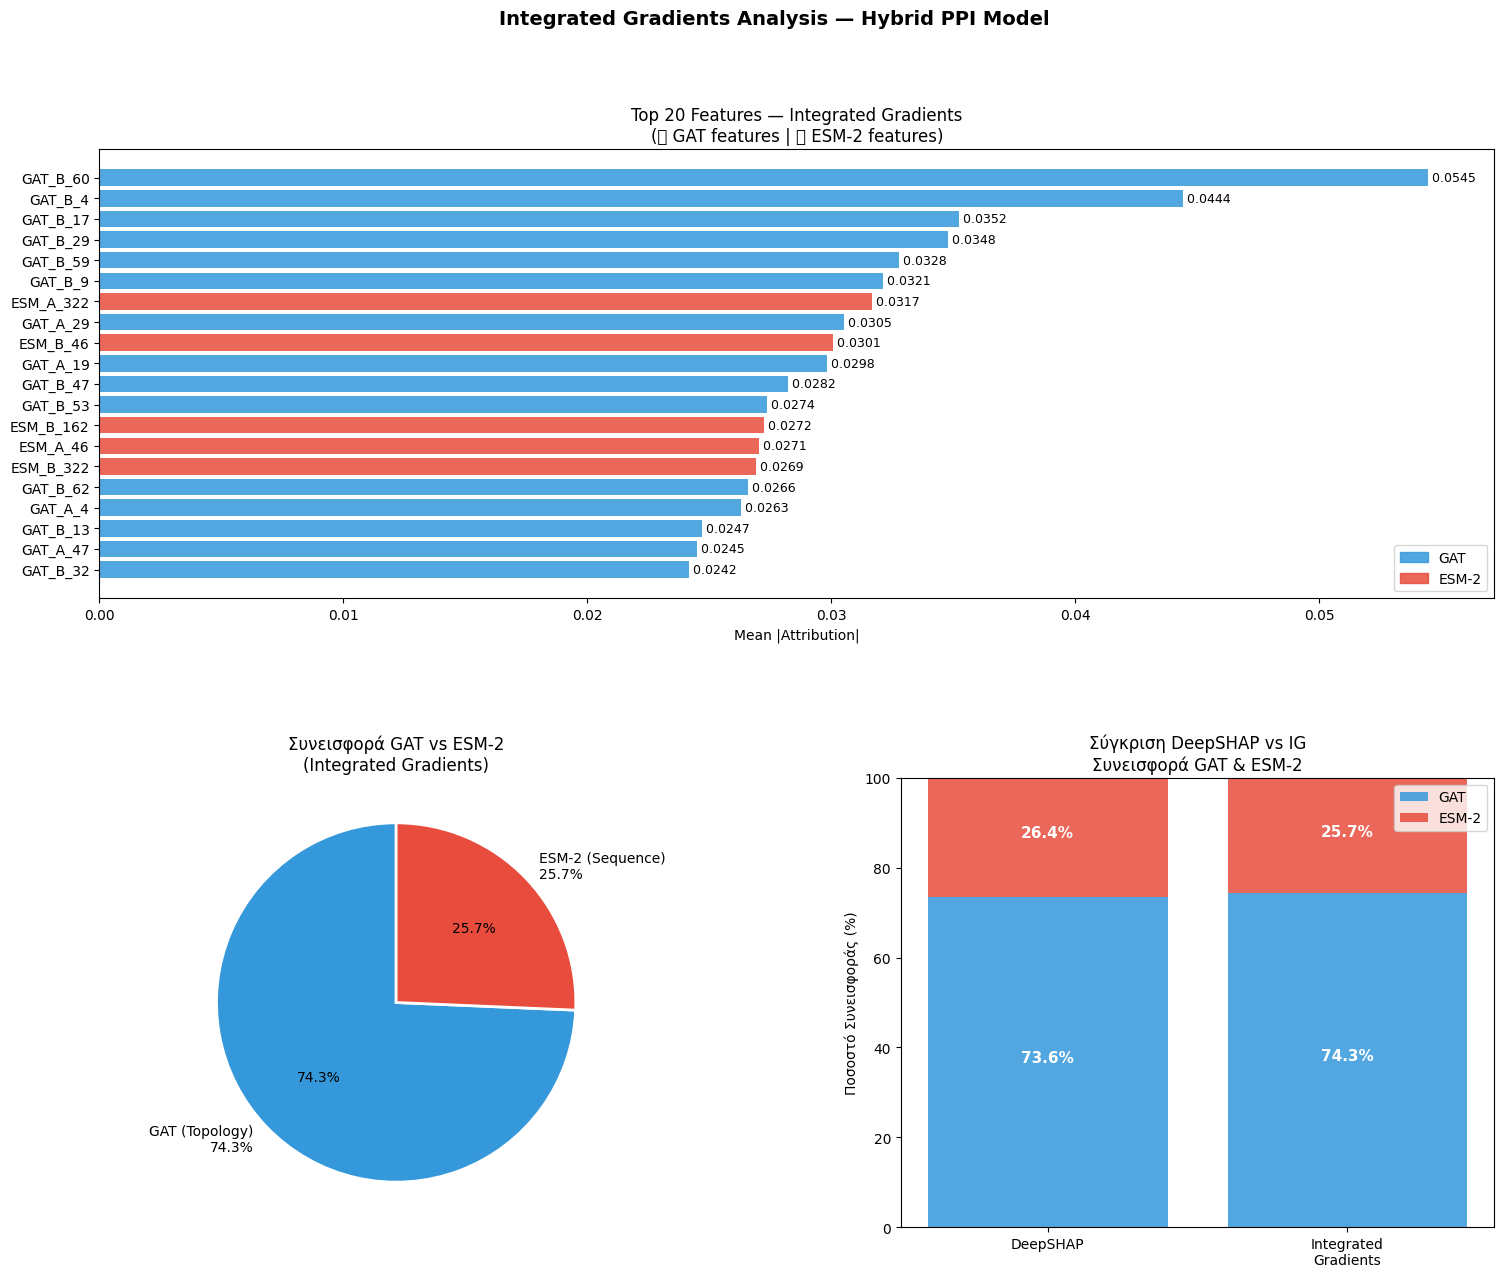

✅ Αποθηκεύτηκε: ig_analysis.png


In [ ]:
# ============================================================
# ΚΕΛΙ 17: IG — ΓΡΑΦΗΜΑΤΑ
# ============================================================

gat_dim = gat_emb.shape[1]    # 64
esm_dim = aligned_esm_emb.shape[1]  # 480

# Feature names
feature_names = (
    [f"GAT_A_{i}" for i in range(gat_dim)] +
    [f"ESM_A_{i}" for i in range(esm_dim)] +
    [f"GAT_B_{i}" for i in range(gat_dim)] +
    [f"ESM_B_{i}" for i in range(esm_dim)]
)

# Mean absolute attribution per feature
mean_attr = np.abs(attributions_np).mean(axis=0)  # [1088]

# Συνεισφορά ανά πηγή
gat_A = mean_attr[:gat_dim].mean()
esm_A = mean_attr[gat_dim:gat_dim+esm_dim].mean()
gat_B = mean_attr[gat_dim+esm_dim:gat_dim+esm_dim+gat_dim].mean()
esm_B = mean_attr[gat_dim+esm_dim+gat_dim:].mean()
total = gat_A + esm_A + gat_B + esm_B

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── Γράφημα 1: Top 20 Features ──────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
top20_feat_idx = np.argsort(mean_attr)[::-1][:20]
top20_vals     = mean_attr[top20_feat_idx]
top20_names    = [feature_names[i] for i in top20_feat_idx]
colors_feat    = ["#3498db" if "GAT" in n else "#e74c3c"
                  for n in top20_names]

bars = ax1.barh(top20_names[::-1], top20_vals[::-1],
                color=colors_feat[::-1], alpha=0.85)
for bar in bars:
    ax1.text(bar.get_width(), bar.get_y()+bar.get_height()/2,
             f" {bar.get_width():.4f}", va="center", fontsize=9)
ax1.set(title="Top 20 Features — Integrated Gradients\n"
              "(🔵 GAT features | 🔴 ESM-2 features)",
        xlabel="Mean |Attribution|")
ax1.legend(handles=[
    plt.Rectangle((0,0),1,1, color="#3498db", alpha=0.85, label="GAT"),
    plt.Rectangle((0,0),1,1, color="#e74c3c", alpha=0.85, label="ESM-2")
], loc="lower right")

# ── Γράφημα 2: GAT vs ESM-2 Pie ─────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
gat_total = gat_A + gat_B
esm_total = esm_A + esm_B
ax2.pie(
    [gat_total, esm_total],
    labels=[f"GAT (Topology)\n{gat_total/total*100:.1f}%",
            f"ESM-2 (Sequence)\n{esm_total/total*100:.1f}%"],
    colors=["#3498db", "#e74c3c"],
    autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor":"white","linewidth":2}
)
ax2.set_title("Συνεισφορά GAT vs ESM-2\n(Integrated Gradients)")

# ── Γράφημα 3: Σύγκριση SHAP vs IG ─────────────────────────
ax3 = fig.add_subplot(gs[1, 1])

# SHAP values (από Κελί 7)
shap_mean = np.abs(shap_arr).mean(axis=0)
gat_A_shap = shap_mean[:gat_dim].mean()
esm_A_shap = shap_mean[gat_dim:gat_dim+esm_dim].mean()
gat_B_shap = shap_mean[gat_dim+esm_dim:gat_dim+esm_dim+gat_dim].mean()
esm_B_shap = shap_mean[gat_dim+esm_dim+gat_dim:].mean()

methods  = ["DeepSHAP", "Integrated\nGradients"]
gat_vals = [gat_A_shap+gat_B_shap, gat_total]
esm_vals = [esm_A_shap+esm_B_shap, esm_total]

# Normalize
gat_pct = [g/(g+e)*100 for g,e in zip(gat_vals, esm_vals)]
esm_pct = [e/(g+e)*100 for g,e in zip(gat_vals, esm_vals)]

x = np.arange(len(methods))
ax3.bar(x, gat_pct, label="GAT", color="#3498db", alpha=0.85)
ax3.bar(x, esm_pct, bottom=gat_pct, label="ESM-2",
        color="#e74c3c", alpha=0.85)
for i, (g, e) in enumerate(zip(gat_pct, esm_pct)):
    ax3.text(i, g/2,    f"{g:.1f}%", ha="center",
             fontweight="bold", color="white", fontsize=11)
    ax3.text(i, g+e/2,  f"{e:.1f}%", ha="center",
             fontweight="bold", color="white", fontsize=11)
ax3.set(xticks=x, xticklabels=methods,
        ylim=[0,100], ylabel="Ποσοστό Συνεισφοράς (%)",
        title="Σύγκριση DeepSHAP vs IG\nΣυνεισφορά GAT & ESM-2")
ax3.legend()

plt.suptitle("Integrated Gradients Analysis — Hybrid PPI Model",
             fontsize=14, fontweight="bold")
plt.savefig("ig_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Αποθηκεύτηκε: ig_analysis.png")